# Breast Tumour 3D Segmentation — DynUNet Pipeline Notebook

**Model:** DynUNet 3D (deep supervision, residual blocks)  
**Data:** Preprocessed `.npy` volumes — `data/patients_combined/` (1.5mm isotropic)  
**Input:** 3-channel DCE-MRI (P1 early, P2 mid, P3 late contrast)  
**GPU:** RTX 2000 Ada 16GB  

### Cells in this notebook
```
Cell 1  — Environment check + GPU info
Cell 2  — Dataset inspection (shapes, tumor stats)
Cell 3  — Visualise raw preprocessed volumes with GT overlay
Cell 4  — Model definition + parameter count
Cell 5  — Training curves (loss, Dice, Precision, Recall)
Cell 6  — Threshold sweep on validation set
Cell 7  — Inference on test set (sliding window + TTA)
Cell 8  — GT mask vs Predicted mask overlay (slice + probability map)
Cell 9  — 3D volume rendering: GT vs prediction (MIP + surface)
Cell 10 — Per-patient evaluation table
Cell 11 — Full summary card
```
> **Note:** Training is NOT run from this notebook. Run `train_dynunet.py` separately.  
> This notebook loads the already-trained model and evaluates it.


In [4]:
# ============================================================
# CELL 1 — Environment check + GPU info
# ============================================================
import os, sys, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from IPython.display import display
import pandas as pd

warnings.filterwarnings('ignore')

# ---- GPU ----
assert torch.cuda.is_available(), 'No CUDA GPU found — this notebook requires a GPU.'
device   = torch.device('cuda')
torch.cuda.set_device(0)
gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
is_ada   = 'Ada' in gpu_name or 'RTX 20' in gpu_name
is_3050  = '3050' in gpu_name

print('=' * 55)
print('  DynUNet 3D Pipeline — Environment')
print('=' * 55)
print(f'  PyTorch  : {torch.__version__}')
print(f'  GPU      : {gpu_name}')
print(f'  VRAM     : {vram_gb:.1f} GB')
print(f'  Device   : {device}')

import monai
print(f'  MONAI    : {monai.__version__}')

# ── PROJECT ROOT ───────────────────────────────────────────────────
_cwd = os.getcwd()

if os.path.basename(_cwd).lower() in ('notebooks', 'notebook'):
    PROJECT_ROOT = os.path.dirname(_cwd)
elif not os.path.exists(os.path.join(_cwd, 'src\segmentation')):
    _parent = os.path.dirname(_cwd)
    if os.path.exists(os.path.join(_parent, 'src\segmentation')):
        PROJECT_ROOT = _parent
    else:
        PROJECT_ROOT = r'D:\Breast_Tumor_AI_Project'  # fallback
else:
    PROJECT_ROOT = _cwd

os.chdir(PROJECT_ROOT)
print(f'  Project  : {PROJECT_ROOT}')
print(f'  CWD set  : {os.getcwd()}')

# ── SOURCE PATH ────────────────────────────────────────────────────
SRC_DIR = os.path.join(PROJECT_ROOT, 'src\segmentation')

if not os.path.exists(SRC_DIR):
    raise FileNotFoundError(
        f'Source folder not found: {SRC_DIR}\n'
        f'Edit PROJECT_ROOT above to point to your project root.'
    )

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f'  Src dir  : {SRC_DIR}')

# Quick import test
try:
    from data_3d       import PATCH_SIZE, _build_data_list, NpyDataset, get_val_transforms
    from model_dynunet import get_dynunet, DYNUNET_CONFIG
    print(f'  Imports  : OK  (PATCH_SIZE={PATCH_SIZE})')
except ImportError as e:
    raise ImportError(
        f'Cannot import data_3d / model_dynunet: {e}\n'
        f'Check that {SRC_DIR} contains data_3d.py and model_dynunet.py'
    )

# ── PATHS ──────────────────────────────────────────────────────────
PREPROCESSED_ROOT = os.path.join(PROJECT_ROOT, 'data', 'patients_combined')
MODEL_DIR         = os.path.join(PROJECT_ROOT, 'models', 'dynunet_3d')
OUTPUT_DIR        = os.path.join(PROJECT_ROOT, 'outputs', 'dynunet_predictions')
HISTORY_FILE      = os.path.join(PROJECT_ROOT, 'training_history_dynunet.npy')
BASELINE_2D_DICE  = 0.7501
MONAI_VAL_DICE    = 0.6652   # update after evaluate_3d.py runs

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify preprocessed data exists and count patients
if not os.path.exists(PREPROCESSED_ROOT):
    print(f'  WARNING: Preprocessed data not found at {PREPROCESSED_ROOT}')
    print(f'           Run combine_and_split.py first.')
else:
    for split in ['train', 'val', 'test']:
        sp = os.path.join(PREPROCESSED_ROOT, split)
        n  = len([d for d in os.listdir(sp)
                  if os.path.isdir(os.path.join(sp, d))]) if os.path.exists(sp) else 0
        print(f'  {split:5s} patients : {n}')

print(f'\n  [Config] DynUNet — filters (32,64,128,256,320), patch 96\u00b3, deep supervision')
print('\n  Ready.')


  DynUNet 3D Pipeline — Environment
  PyTorch  : 2.5.1+cu121
  GPU      : NVIDIA RTX 2000 Ada Generation
  VRAM     : 17.2 GB
  Device   : cuda
  MONAI    : 1.5.2
  Project  : E:\Breast_Tumor_AI_Project
  CWD set  : E:\Breast_Tumor_AI_Project
  Src dir  : E:\Breast_Tumor_AI_Project\src\segmentation
  Imports  : OK  (PATCH_SIZE=(96, 96, 96))
  train patients : 163
  val   patients : 34
  test  patients : 36

  [Config] DynUNet — filters (32,64,128,256,320), patch 96³, deep supervision

  Ready.


Loading dataset statistics (reads all .npy files)...

  TRAIN (163 patients)
    Volume D : 40–241  H : 72–352  W : 104–352
    Tumor voxels : 150 – 109,481  (mean 8275)
    Tumor ratio  : 0.0115% – 5.2272%  (mean 0.4150%)

  VAL (34 patients)
    Volume D : 40–241  H : 70–352  W : 104–352
    Tumor voxels : 107 – 13,968  (mean 4573)
    Tumor ratio  : 0.0038% – 0.9334%  (mean 0.2350%)

  TEST (36 patients)
    Volume D : 40–241  H : 82–352  W : 107–352
    Tumor voxels : 197 – 33,244  (mean 4869)
    Tumor ratio  : 0.0087% – 2.0126%  (mean 0.2335%)


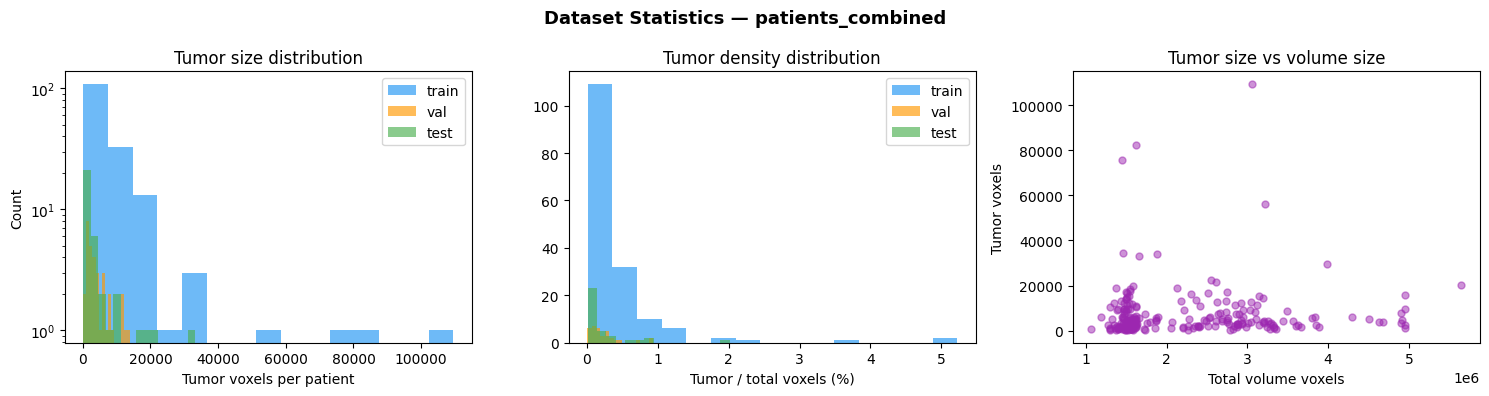

Saved: outputs/dataset_statistics_dynunet.png


In [5]:
# ============================================================
# CELL 2 — Dataset inspection
# ============================================================
def inspect_split(split_name):
    data_list = _build_data_list(PREPROCESSED_ROOT, split_name)
    shapes, tumor_voxels, ratios = [], [], []
    for entry in data_list:
        img = np.load(entry['image'])
        lbl = np.load(entry['label'])
        shapes.append(img.shape)
        tv  = int((lbl > 0).sum())
        tumor_voxels.append(tv)
        ratios.append(tv / lbl.size * 100)
    return data_list, shapes, tumor_voxels, ratios

print('Loading dataset statistics (reads all .npy files)...')
splits = {}
for spl in ['train', 'val', 'test']:
    dl, sh, tv, rt = inspect_split(spl)
    splits[spl] = {'data': dl, 'shapes': sh, 'tumor_voxels': tv, 'ratios': rt}
    D = [s[1] for s in sh]; H = [s[2] for s in sh]; W = [s[3] for s in sh]
    if len(dl) == 0:
        print(f'\n  {spl.upper()} (0 patients) — check PREPROCESSED_ROOT path!')
        continue
    print(f'\n  {spl.upper()} ({len(dl)} patients)')
    print(f'    Volume D : {min(D)}\u2013{max(D)}  H : {min(H)}\u2013{max(H)}  W : {min(W)}\u2013{max(W)}')
    print(f'    Tumor voxels : {min(tv):,} \u2013 {max(tv):,}  (mean {np.mean(tv):.0f})')
    print(f'    Tumor ratio  : {min(rt):.4f}% \u2013 {max(rt):.4f}%  (mean {np.mean(rt):.4f}%)')

# ---- Dataset stats plot ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Statistics — patients_combined', fontsize=13, fontweight='bold')
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

ax = axes[0]
for spl, c in colors.items():
    ax.hist(splits[spl]['tumor_voxels'], bins=15, alpha=0.65, color=c, label=spl)
ax.set_xlabel('Tumor voxels per patient')
ax.set_ylabel('Count')
ax.set_title('Tumor size distribution')
ax.legend()
ax.set_yscale('log')

ax = axes[1]
for spl, c in colors.items():
    ax.hist(splits[spl]['ratios'], bins=15, alpha=0.65, color=c, label=spl)
ax.set_xlabel('Tumor / total voxels (%)')
ax.set_title('Tumor density distribution')
ax.legend()

ax = axes[2]
all_tv = splits['train']['tumor_voxels'] + splits['val']['tumor_voxels'] + splits['test']['tumor_voxels']
all_sh = splits['train']['shapes'] + splits['val']['shapes'] + splits['test']['shapes']
vols   = [s[1]*s[2]*s[3] for s in all_sh]
ax.scatter(vols, all_tv, alpha=0.5, color='#9C27B0', s=25)
ax.set_xlabel('Total volume voxels')
ax.set_ylabel('Tumor voxels')
ax.set_title('Tumor size vs volume size')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'dataset_statistics_dynunet.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/dataset_statistics_dynunet.png')



--- Small tumor (voxels: 946) ---


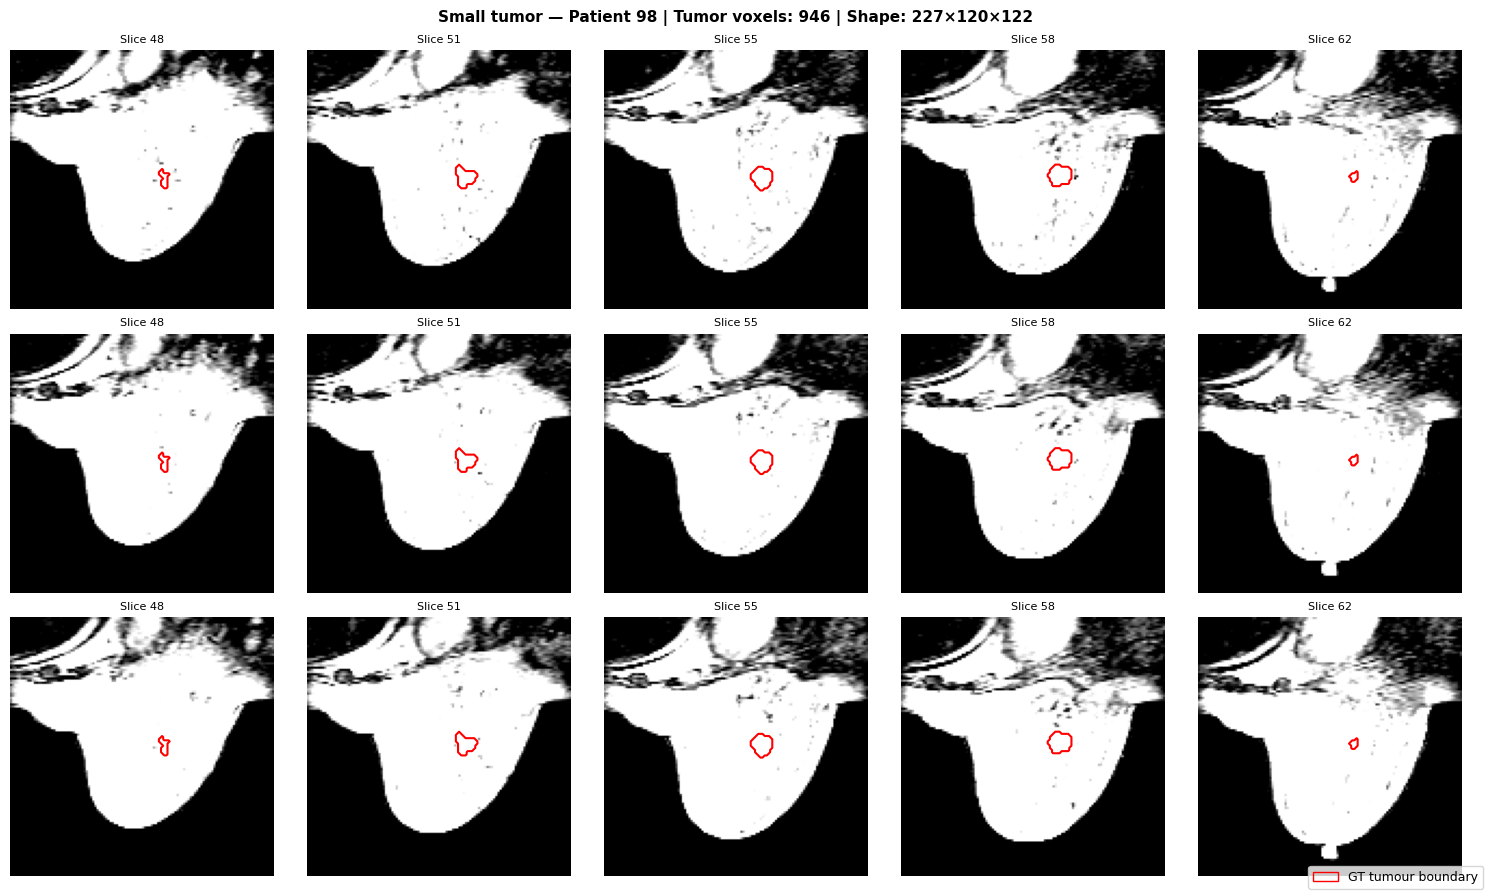


--- Median tumor (voxels: 4,668) ---


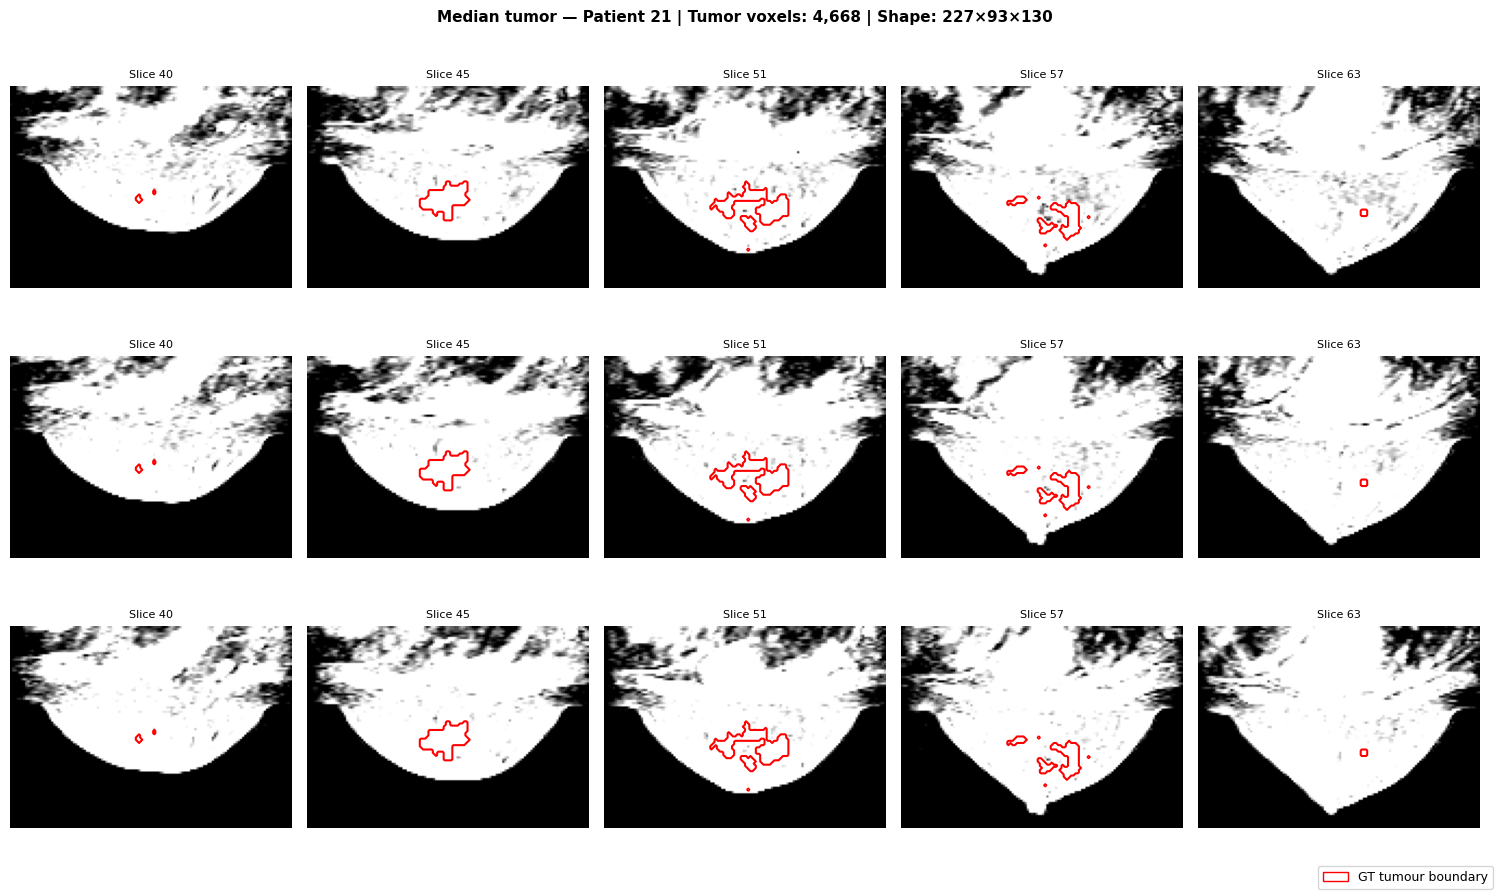


--- Large tumor (voxels: 16,700) ---


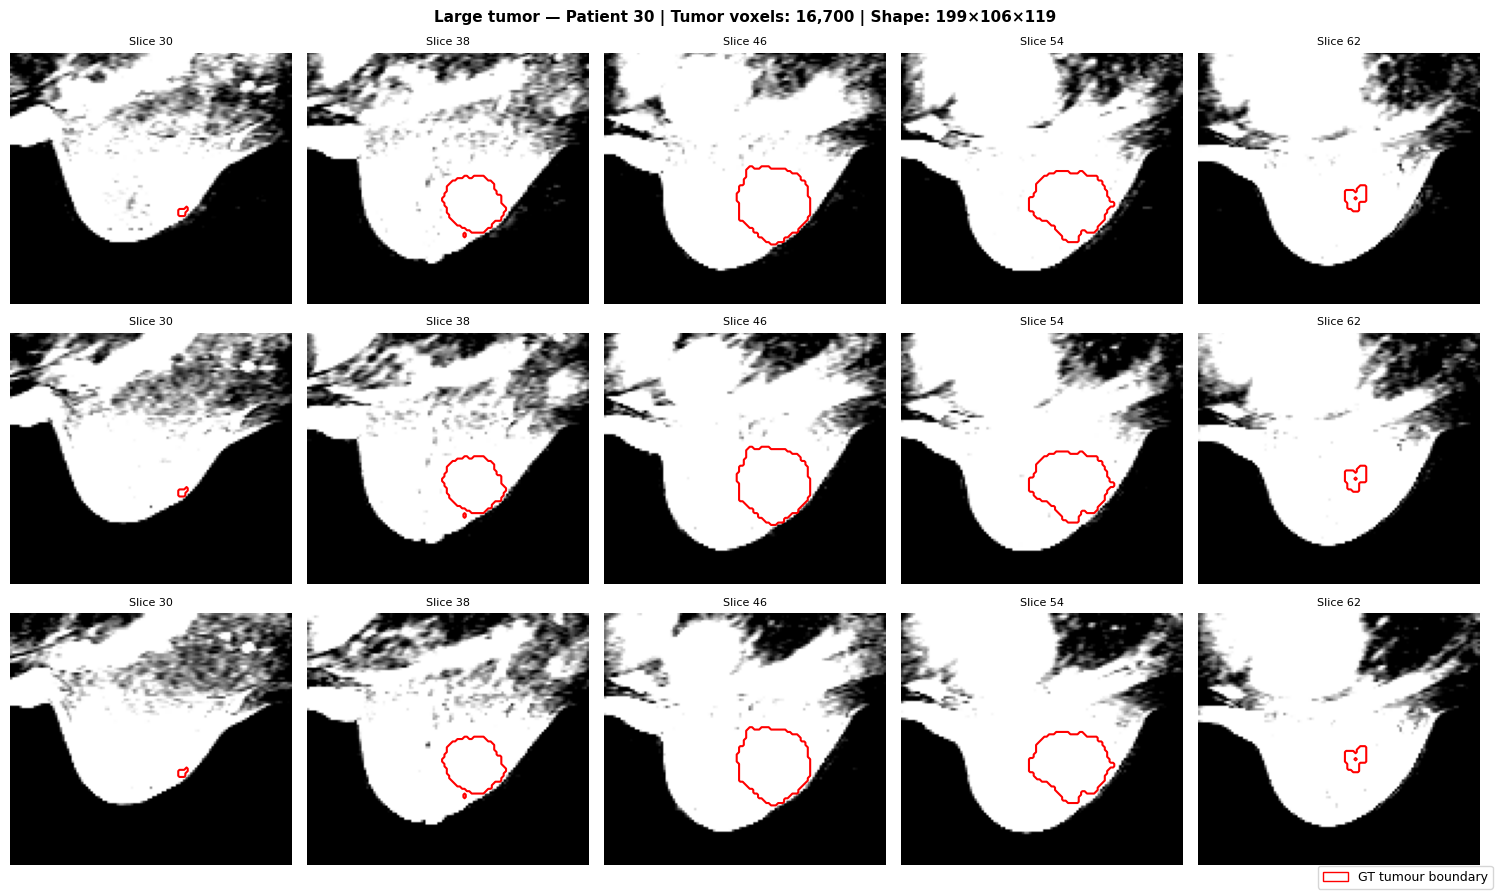

In [6]:
# ============================================================
# CELL 3 — Visualise raw preprocessed volumes with GT overlay
# Shows 3 representative patients: small, medium, large tumor
# ============================================================
def show_volume_slices(patient_entry, title='', n_slices=5):
    """Show axial slices through the volume with GT mask overlay."""
    img = np.load(patient_entry['image'])  # (3, D, H, W)
    lbl = np.load(patient_entry['label'])  # (1, D, H, W)
    pid = patient_entry['patient_id']

    lbl_sq = lbl.squeeze()
    tumor_slices = np.where(lbl_sq.sum(axis=(1, 2)) > 0)[0]

    if len(tumor_slices) == 0:
        print(f'  Patient {pid}: no tumor voxels found in label')
        return

    indices = np.linspace(tumor_slices[0], tumor_slices[-1], n_slices, dtype=int)

    fig, axes = plt.subplots(3, n_slices, figsize=(n_slices * 3, 9))
    fig.suptitle(
        f'{title} — Patient {pid} | '
        f'Tumor voxels: {int((lbl>0).sum()):,} | '
        f'Shape: {img.shape[1]}\u00d7{img.shape[2]}\u00d7{img.shape[3]}',
        fontsize=11, fontweight='bold'
    )

    channel_names = ['P1 (early)', 'P2 (mid)', 'P3 (late)']

    for col, sl in enumerate(indices):
        for row in range(3):
            ax = axes[row, col]
            ax.imshow(img[row, sl, :, :], cmap='gray', vmin=0, vmax=1)
            mask_sl = lbl_sq[sl, :, :]
            if mask_sl.sum() > 0:
                ax.contour(mask_sl, levels=[0.5], colors='red', linewidths=1.5)
            if col == 0:
                ax.set_ylabel(channel_names[row], fontsize=9)
            ax.set_title(f'Slice {sl}', fontsize=8)
            ax.axis('off')

    patch = mpatches.Patch(edgecolor='red', facecolor='none', label='GT tumour boundary')
    fig.legend(handles=[patch], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'outputs/patient_{pid}_slices.png', dpi=100, bbox_inches='tight')
    plt.show()

if 'train' not in splits or len(splits['train']['data']) == 0:
    print('Train split empty — check PREPROCESSED_ROOT in Cell 1.')
else:
    train_list = splits['train']['data']
    tvs        = splits['train']['tumor_voxels']
    sorted_idx = np.argsort(tvs)
    n          = len(sorted_idx)

    small_idx  = sorted_idx[max(0, n // 10)]
    median_idx = sorted_idx[n // 2]
    large_idx  = sorted_idx[min(n - 1, int(n * 0.9))]

    for idx, label in [(small_idx, 'Small tumor'), (median_idx, 'Median tumor'), (large_idx, 'Large tumor')]:
        print(f'\n--- {label} (voxels: {tvs[idx]:,}) ---')
        show_volume_slices(train_list[idx], title=label)


In [7]:
# ============================================================
# CELL 4 — Model definition + parameter count
# ============================================================
import math
from model_dynunet import get_dynunet, DYNUNET_CONFIG, OUTPUT_BIAS_INIT

model = get_dynunet(device)

total  = sum(p.numel() for p in model.parameters())
bias_s = torch.sigmoid(torch.tensor(OUTPUT_BIAS_INIT)).item()

print('\n  Architecture summary (DynUNet):')
print(f'    Spatial dims    : {DYNUNET_CONFIG["spatial_dims"]}D')
print(f'    Input channels  : {DYNUNET_CONFIG["in_channels"]} (P1, P2, P3)')
print(f'    Filters         : {DYNUNET_CONFIG["filters"]}')
print(f'    Norm            : {DYNUNET_CONFIG["norm_name"]}')
print(f'    Residual blocks : {DYNUNET_CONFIG["res_block"]}')
print(f'    Deep supervision: {DYNUNET_CONFIG["deep_supervision"]}  (heads: {DYNUNET_CONFIG["deep_supr_num"]})')
print(f'    Output bias     : {OUTPUT_BIAS_INIT:.4f}  (sigmoid = {bias_s:.5f})')
print(f'    Total params    : {total:,}')
print(f'    Precision       : BF16 mixed (torch.amp)')

from data_3d import PATCH_SIZE
batch    = 2
patch_vx = PATCH_SIZE[0] * PATCH_SIZE[1] * PATCH_SIZE[2]
input_mb = batch * 3 * patch_vx * 2 / 1e6
wt_mb    = total * 4 / 1e6
print(f'\n  VRAM estimate (batch {batch}, patch {PATCH_SIZE[0]}\u00b3, BF16):')
print(f'    Input tensor     : ~{input_mb:.0f} MB')
print(f'    Weights (fp32)   : ~{wt_mb:.0f} MB')
print(f'    Deep supervision : +~20% activation overhead vs single-output model')
print(f'    Should fit on    : {vram_gb:.1f} GB GPU')


  Output bias layer : output_block.conv.conv.bias
  Output bias init  : -7.6004  (sigmoid = 0.00050  ≈ tumour prevalence)
Model : DynUNet 3D (deep supervision)
  Total params     : 16,665,443
  Trainable        : 16,665,443
  Device           : cuda

  Architecture summary (DynUNet):
    Spatial dims    : 3D
    Input channels  : 3 (P1, P2, P3)
    Filters         : (32, 64, 128, 256, 320)
    Norm            : instance
    Residual blocks : True
    Deep supervision: True  (heads: 2)
    Output bias     : -7.6004  (sigmoid = 0.00050)
    Total params    : 16,665,443
    Precision       : BF16 mixed (torch.amp)

  VRAM estimate (batch 2, patch 96³, BF16):
    Input tensor     : ~11 MB
    Weights (fp32)   : ~67 MB
    Deep supervision : +~20% activation overhead vs single-output model
    Should fit on    : 17.2 GB GPU


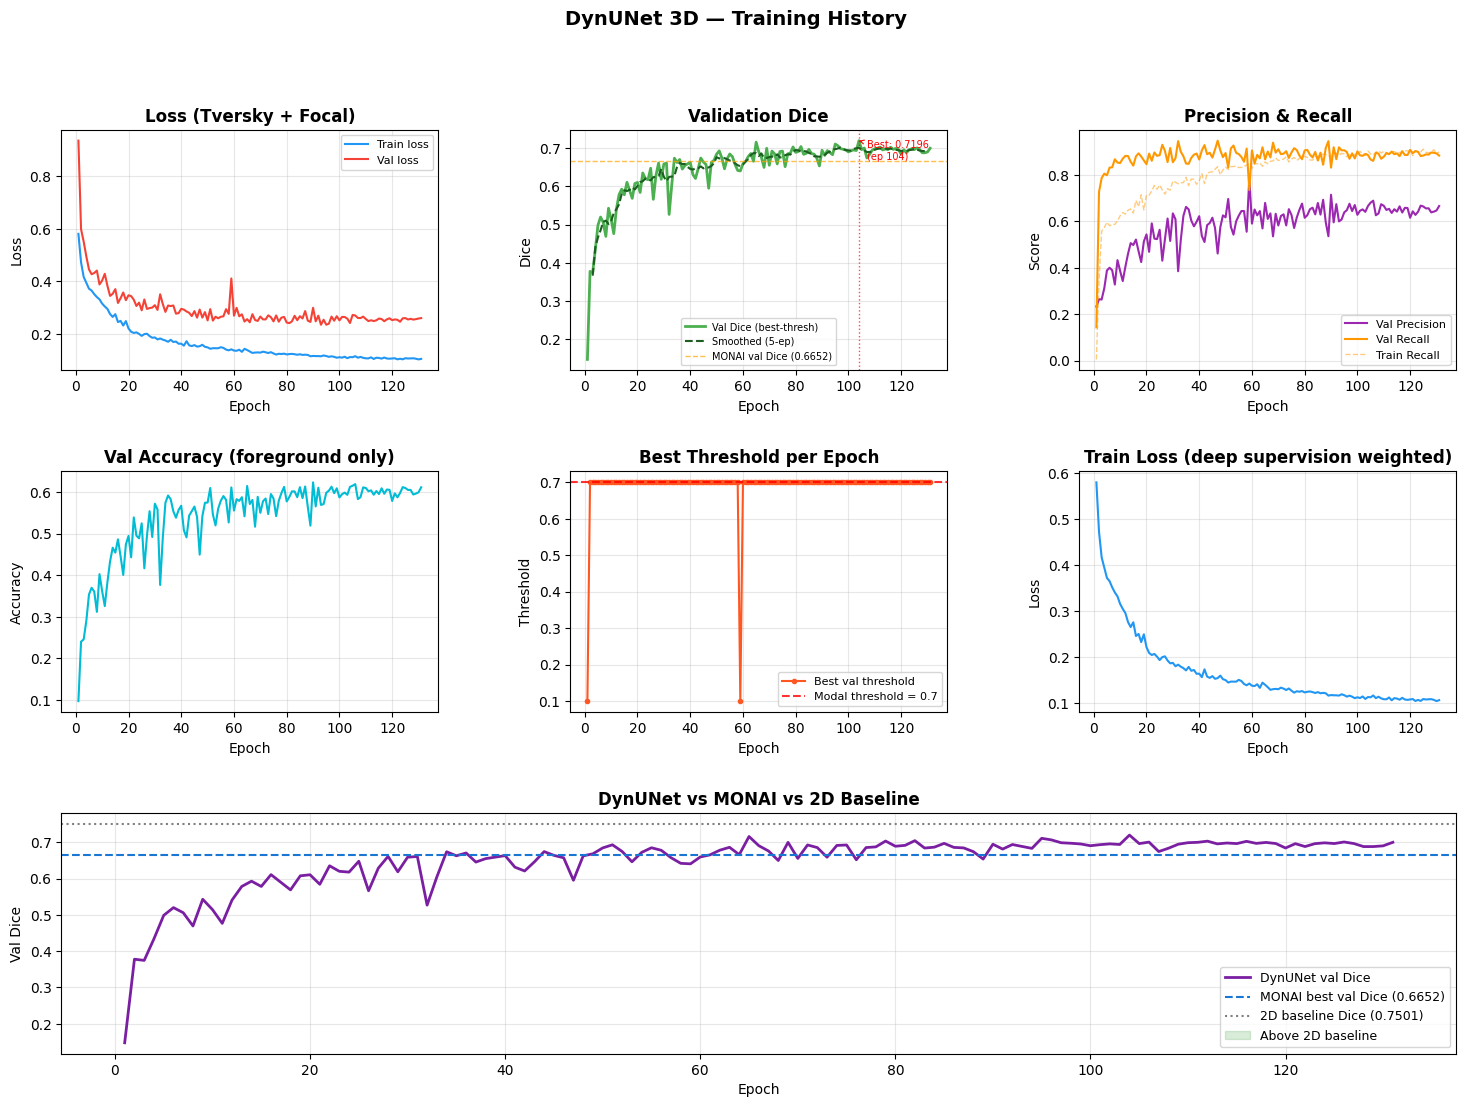

Saved: outputs/training_curves_dynunet.png

  Epochs trained     : 131
  Best val Dice      : 0.7196  (epoch 104)
  MONAI best val     : 0.6652
  DynUNet vs MONAI   : +0.0544


In [8]:
# ============================================================
# CELL 5 — Training curves
# Loads training_history_dynunet.npy and plots all metrics
# ============================================================
if not os.path.exists(HISTORY_FILE):
    print(f'History file not found: {HISTORY_FILE}')
    print('Run train_dynunet.py first, then re-run this cell.')
else:
    history = np.load(HISTORY_FILE, allow_pickle=True).item()

    epochs_done = len(history['val_dice'])
    ep = np.arange(1, epochs_done + 1)

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('DynUNet 3D — Training History', fontsize=14, fontweight='bold')
    gs = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

    # --- 1. Loss ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(ep, history['train_loss'], color='#2196F3', lw=1.5, label='Train loss')
    ax1.plot(ep, history['val_loss'],   color='#F44336', lw=1.5, label='Val loss')
    ax1.set_title('Loss (Tversky + Focal)', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    # --- 2. Val Dice ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(ep, history['val_dice'], color='#4CAF50', lw=2, label='Val Dice (best-thresh)')
    if len(history['val_dice']) >= 5:
        smooth = np.convolve(history['val_dice'], np.ones(5) / 5, mode='valid')
        ax2.plot(np.arange(3, 3 + len(smooth)), smooth, color='#1B5E20', lw=1.5,
                 linestyle='--', label='Smoothed (5-ep)')
    best_ep = int(np.argmax(history['val_dice'])) + 1
    best_d  = max(history['val_dice'])
    ax2.axvline(best_ep, color='red', lw=1, linestyle=':', alpha=0.7)
    ax2.annotate(f'Best: {best_d:.4f}\n(ep {best_ep})',
                 xy=(best_ep, best_d), xytext=(best_ep + 3, best_d - 0.05),
                 fontsize=7, color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
    # Reference line: MONAI val Dice
    ax2.axhline(MONAI_VAL_DICE, color='orange', lw=1, linestyle='--', alpha=0.7,
                label=f'MONAI val Dice ({MONAI_VAL_DICE:.4f})')
    ax2.set_title('Validation Dice', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice')
    ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

    # --- 3. Precision & Recall ---
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(ep, history['val_precision'], color='#9C27B0', lw=1.5, label='Val Precision')
    ax3.plot(ep, history['val_recall'],    color='#FF9800', lw=1.5, label='Val Recall')
    ax3.plot(ep, history['train_recall'],  color='#FF9800', lw=1,
             linestyle='--', alpha=0.5, label='Train Recall')
    ax3.set_title('Precision & Recall', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Score')
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

    # --- 4. Val Accuracy ---
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(ep, history['val_accuracy'], color='#00BCD4', lw=1.5)
    ax4.set_title('Val Accuracy (foreground only)', fontweight='bold')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Accuracy')
    ax4.grid(alpha=0.3)

    # --- 5. Best threshold per epoch ---
    ax5 = fig.add_subplot(gs[1, 1])
    if 'val_best_thresh' in history and len(history['val_best_thresh']) > 0:
        ax5.plot(ep, history['val_best_thresh'], 'o-', color='#FF5722',
                 lw=1.5, ms=3, label='Best val threshold')
        from collections import Counter
        modal = Counter(history['val_best_thresh']).most_common(1)[0][0]
        ax5.axhline(modal, color='red', lw=1.5, linestyle='--', alpha=0.8,
                    label=f'Modal threshold = {modal}')
        ax5.set_title('Best Threshold per Epoch', fontweight='bold')
        ax5.set_xlabel('Epoch'); ax5.set_ylabel('Threshold')
        ax5.legend(fontsize=8); ax5.grid(alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'val_best_thresh\nnot in history',
                 ha='center', va='center', transform=ax5.transAxes)

    # --- 6. Deep supervision convergence proxy (train loss) ---
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.plot(ep, history['train_loss'], color='#2196F3', lw=1.5)
    ax6.set_title('Train Loss (deep supervision weighted)', fontweight='bold')
    ax6.set_xlabel('Epoch'); ax6.set_ylabel('Loss')
    ax6.grid(alpha=0.3)

    # --- 7. Val Dice vs MONAI comparison ---
    ax7 = fig.add_subplot(gs[2, :])
    ax7.plot(ep, history['val_dice'], color='#7B1FA2', lw=2, label='DynUNet val Dice')
    ax7.axhline(MONAI_VAL_DICE,  color='#1976D2', lw=1.5, linestyle='--',
                label=f'MONAI best val Dice ({MONAI_VAL_DICE:.4f})')
    ax7.axhline(BASELINE_2D_DICE, color='gray', lw=1.5, linestyle=':',
                label=f'2D baseline Dice ({BASELINE_2D_DICE})')
    ax7.fill_between(ep, history['val_dice'], BASELINE_2D_DICE,
                     where=np.array(history['val_dice']) > BASELINE_2D_DICE,
                     alpha=0.15, color='green', label='Above 2D baseline')
    ax7.set_title('DynUNet vs MONAI vs 2D Baseline', fontweight='bold')
    ax7.set_xlabel('Epoch'); ax7.set_ylabel('Val Dice')
    ax7.legend(fontsize=9); ax7.grid(alpha=0.3)

    plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'training_curves_dynunet.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: outputs/training_curves_dynunet.png')
    print(f'\n  Epochs trained     : {epochs_done}')
    print(f'  Best val Dice      : {best_d:.4f}  (epoch {best_ep})')
    print(f'  MONAI best val     : {MONAI_VAL_DICE:.4f}')
    print(f'  DynUNet vs MONAI   : {best_d - MONAI_VAL_DICE:+.4f}')


  Output bias layer : output_block.conv.conv.bias
  Output bias init  : -7.6004  (sigmoid = 0.00050  ≈ tumour prevalence)
Model : DynUNet 3D (deep supervision)
  Total params     : 16,665,443
  Trainable        : 16,665,443
  Device           : cuda
Model loaded: E:\Breast_Tumor_AI_Project\models\dynunet_3d\dynunet_best_raw.pth

Sweeping 9 thresholds on 34 val patients...

  Threshold sweep results:
     Threshold |  Mean Dice
  -------------+-----------
          0.05 |     0.6910
          0.10 |     0.6977
          0.20 |     0.7026
          0.30 |     0.7055
          0.40 |     0.7077
          0.50 |     0.7096
          0.60 |     0.7111
          0.70 |     0.7123
          0.80 |     0.7136 ← BEST

  Optimal threshold : 0.8
  Set THRESHOLD = 0.8 in predict_dynunet.py


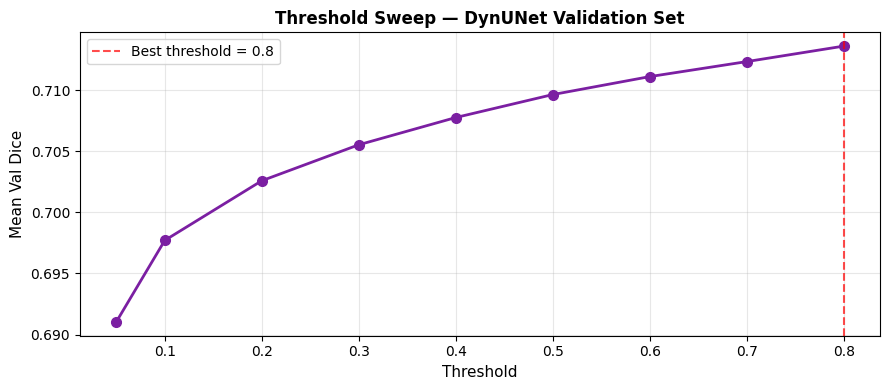

Saved: outputs/threshold_sweep_dynunet.png


In [9]:
# ============================================================
# CELL 6 — Threshold sweep on validation set
# Finds the best global threshold for predict_dynunet.py
# ============================================================
from torch.utils.data import DataLoader
from monai.inferers import sliding_window_inference
from torch.amp import autocast

MODEL_PATH = os.path.join(MODEL_DIR, 'dynunet_best_raw.pth')

assert os.path.exists(MODEL_PATH), \
    f'Model not found: {MODEL_PATH}\nRun train_dynunet.py first.'

# Reload model with trained weights
model = get_dynunet(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()
print(f'Model loaded: {MODEL_PATH}')

THRESHOLDS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

val_list   = _build_data_list(PREPROCESSED_ROOT, 'val')
val_ds     = NpyDataset(val_list, transform=get_val_transforms())
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False,
                        num_workers=0, pin_memory=False)

def compute_dice_np(p, g):
    return 2 * np.logical_and(p, g).sum() / (p.sum() + g.sum() + 1e-8)

print(f'\nSweeping {len(THRESHOLDS)} thresholds on {len(val_list)} val patients...')

thresh_dices = {t: [] for t in THRESHOLDS}

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device)
        labels = batch['label']
        gt_np  = (labels.squeeze().numpy() > 0).astype(bool)
        if gt_np.sum() == 0:
            continue

        with autocast('cuda', dtype=torch.bfloat16):
            logits = sliding_window_inference(
                inputs=images, roi_size=PATCH_SIZE,
                sw_batch_size=2, predictor=model,
                overlap=0.5, mode='gaussian')

        prob = torch.sigmoid(logits.float()).squeeze().cpu().numpy()

        for t in THRESHOLDS:
            pred = (prob > t).astype(bool)
            thresh_dices[t].append(compute_dice_np(pred, gt_np))

mean_dices  = {t: np.mean(v) for t, v in thresh_dices.items()}
BEST_THRESHOLD = max(mean_dices, key=mean_dices.get)

print(f'\n  Threshold sweep results:')
print(f'  {"Threshold":>12} | {"Mean Dice":>10}')
print(f'  {"-"*12}-+-{"-"*10}')
for t, d in sorted(mean_dices.items()):
    marker = ' \u2190 BEST' if t == BEST_THRESHOLD else ''
    print(f'  {t:>12.2f} | {d:>10.4f}{marker}')

print(f'\n  Optimal threshold : {BEST_THRESHOLD}')
print(f'  Set THRESHOLD = {BEST_THRESHOLD} in predict_dynunet.py')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ts = sorted(mean_dices.keys())
ds = [mean_dices[t] for t in ts]
ax.plot(ts, ds, 'o-', color='#7B1FA2', lw=2, markersize=7)
ax.axvline(BEST_THRESHOLD, color='red', lw=1.5, linestyle='--', alpha=0.7,
           label=f'Best threshold = {BEST_THRESHOLD}')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Mean Val Dice', fontsize=11)
ax.set_title('Threshold Sweep — DynUNet Validation Set', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'threshold_sweep_dynunet.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/threshold_sweep_dynunet.png')


In [10]:
# ============================================================
# CELL 7 — Inference on test set (sliding window + TTA)
# ============================================================
from scipy import ndimage
from tqdm.notebook import tqdm

# Use best threshold from Cell 6, or set manually
try:
    INFER_THRESHOLD = BEST_THRESHOLD
except NameError:
    INFER_THRESHOLD = 0.7  # default if Cell 6 was not run

TTA_ENABLED = True
SW_OVERLAP  = 0.5

print(f'Inference config:')
print(f'  Model     : {MODEL_PATH}')
print(f'  Threshold : {INFER_THRESHOLD}')
print(f'  TTA       : {"8 orientations" if TTA_ENABLED else "disabled"}')
print(f'  Patch     : {PATCH_SIZE}')

def predict_volume(image_tensor):
    with torch.no_grad():
        with autocast('cuda', dtype=torch.bfloat16):
            logits = sliding_window_inference(
                inputs=image_tensor, roi_size=PATCH_SIZE,
                sw_batch_size=2, predictor=model,
                overlap=SW_OVERLAP, mode='gaussian')
    return torch.sigmoid(logits.float()).squeeze().cpu().numpy().astype(np.float32)

def predict_with_tta(image_tensor):
    img_np   = image_tensor.squeeze(0).cpu().numpy()
    prob_sum = predict_volume(image_tensor)
    for axes in [(2,), (3,), (4,), (2, 3), (2, 4), (3, 4), (2, 3, 4)]:
        flipped_np = np.flip(img_np, axis=[a - 1 for a in axes]).copy()
        flipped_t  = torch.tensor(flipped_np).unsqueeze(0).float().to(device)
        prob_flip  = predict_volume(flipped_t)
        prob_sum  += np.flip(prob_flip, axis=[a - 2 for a in axes]).copy()
    return (prob_sum / 8).astype(np.float32)

def post_process(binary_mask, min_size_voxels=200):
    struct  = ndimage.generate_binary_structure(3, 1)
    closed  = ndimage.binary_closing(binary_mask, structure=struct, iterations=2)
    labeled, n = ndimage.label(closed)
    if n == 0:
        return closed.astype(np.uint8)
    cleaned = np.zeros_like(closed, dtype=np.uint8)
    for i in range(1, n + 1):
        if (labeled == i).sum() >= min_size_voxels:
            cleaned[labeled == i] = 1
    return cleaned

def keep_largest_component(binary_mask):
    labeled, n_features = ndimage.label(binary_mask)
    if n_features == 0:
        return binary_mask
    sizes = ndimage.sum(binary_mask, labeled, range(1, n_features + 1))
    return (labeled == np.argmax(sizes) + 1).astype(np.uint8)

test_list   = _build_data_list(PREPROCESSED_ROOT, 'test')
test_ds     = NpyDataset(test_list, transform=get_val_transforms())
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                         num_workers=0, pin_memory=False)

results          = []
prob_maps_cache  = []  # cache for visualisation in Cell 8 / Cell 9

for idx, batch in enumerate(tqdm(test_loader, desc='DynUNet Inference')):
    images     = batch['image'].to(device)
    labels     = batch['label']
    patient_id = test_list[idx]['patient_id']

    prob_map    = predict_with_tta(images) if TTA_ENABLED else predict_volume(images)
    binary_mask = post_process((prob_map > INFER_THRESHOLD).astype(np.uint8))
    binary_mask = keep_largest_component(binary_mask)

    gt_np   = (labels.squeeze().numpy() > 0).astype(bool)
    pred_np = binary_mask.astype(bool)
    inter   = np.logical_and(pred_np, gt_np).sum()
    dice    = float(2 * inter / (pred_np.sum() + gt_np.sum() + 1e-8))
    iou     = float(inter / (np.logical_or(pred_np, gt_np).sum() + 1e-8))

    results.append({
        'patient_id' : patient_id,
        'dice'       : round(dice, 4),
        'iou'        : round(iou, 4),
        'has_tumor'  : bool(gt_np.sum() > 0),
        'detected'   : bool(pred_np.sum() > 0),
        'gt_voxels'  : int(gt_np.sum()),
        'pred_voxels': int(pred_np.sum()),
    })

    # Cache up to 6 patients for visualisation
    if len(prob_maps_cache) < 6 and gt_np.sum() > 0:
        prob_maps_cache.append({
            'patient_id': patient_id,
            'image'     : batch['image'].squeeze(0).numpy(),
            'gt'        : gt_np,
            'pred'      : pred_np,
            'prob'      : prob_map,
            'dice'      : dice,
        })

tumor_results = [r for r in results if r['has_tumor']]
missed        = sum(1 for r in tumor_results if not r['detected'])
print(f'\nInference complete.')
print(f'  Test patients     : {len(results)}')
print(f'  Tumor patients    : {len(tumor_results)}')
print(f'  Missed tumors     : {missed}')
if tumor_results:
    dices = [r['dice'] for r in tumor_results]
    print(f'  Mean Dice (tumor) : {np.mean(dices):.4f}')
    print(f'  Best Dice         : {np.max(dices):.4f}')
    print(f'  Worst Dice        : {np.min(dices):.4f}')
    print(f'  vs 2D baseline    : {np.mean(dices) - BASELINE_2D_DICE:+.4f}')
    print(f'  vs MONAI val      : {np.mean(dices) - MONAI_VAL_DICE:+.4f}')


Inference config:
  Model     : E:\Breast_Tumor_AI_Project\models\dynunet_3d\dynunet_best_raw.pth
  Threshold : 0.8
  TTA       : 8 orientations
  Patch     : (96, 96, 96)


DynUNet Inference:   0%|          | 0/36 [00:00<?, ?it/s]


Inference complete.
  Test patients     : 36
  Tumor patients    : 36
  Missed tumors     : 5
  Mean Dice (tumor) : 0.5188
  Best Dice         : 0.9582
  Worst Dice        : 0.0000
  vs 2D baseline    : -0.2313
  vs MONAI val      : -0.1464


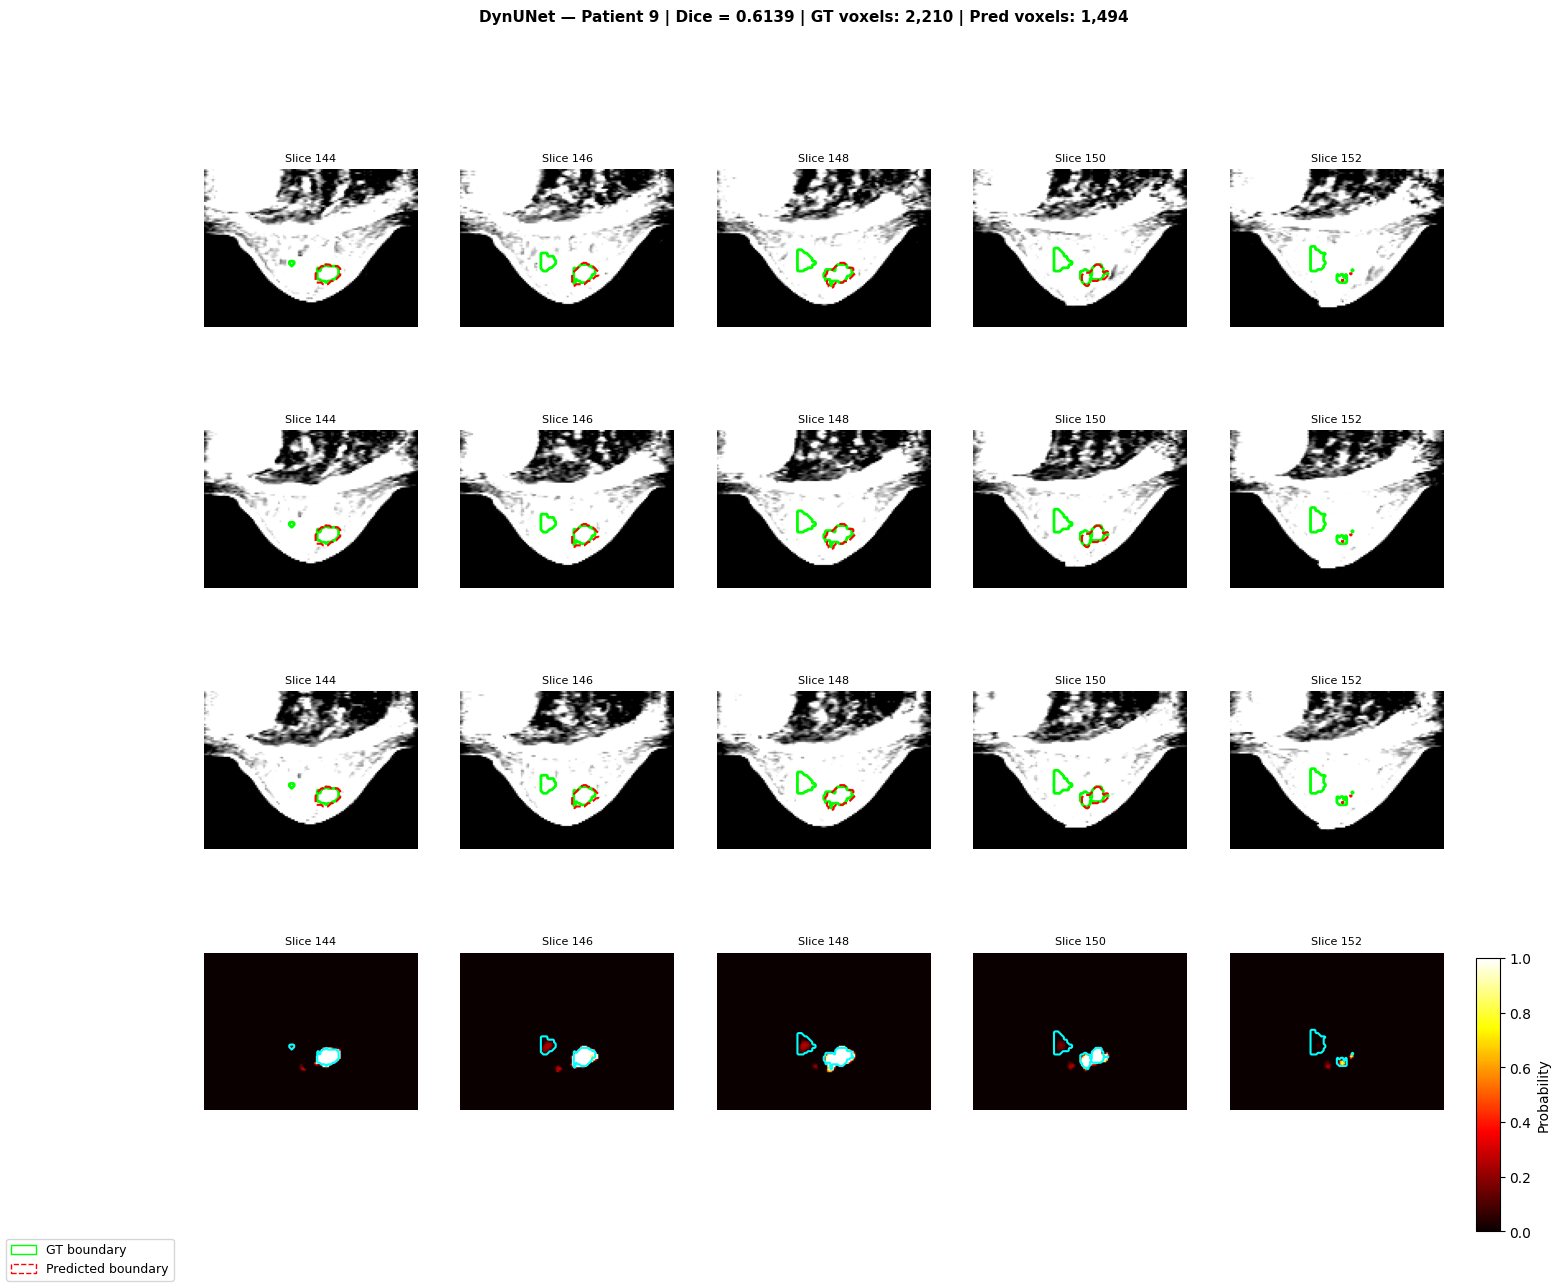

Saved: outputs/dynunet_patient9_overlay.png


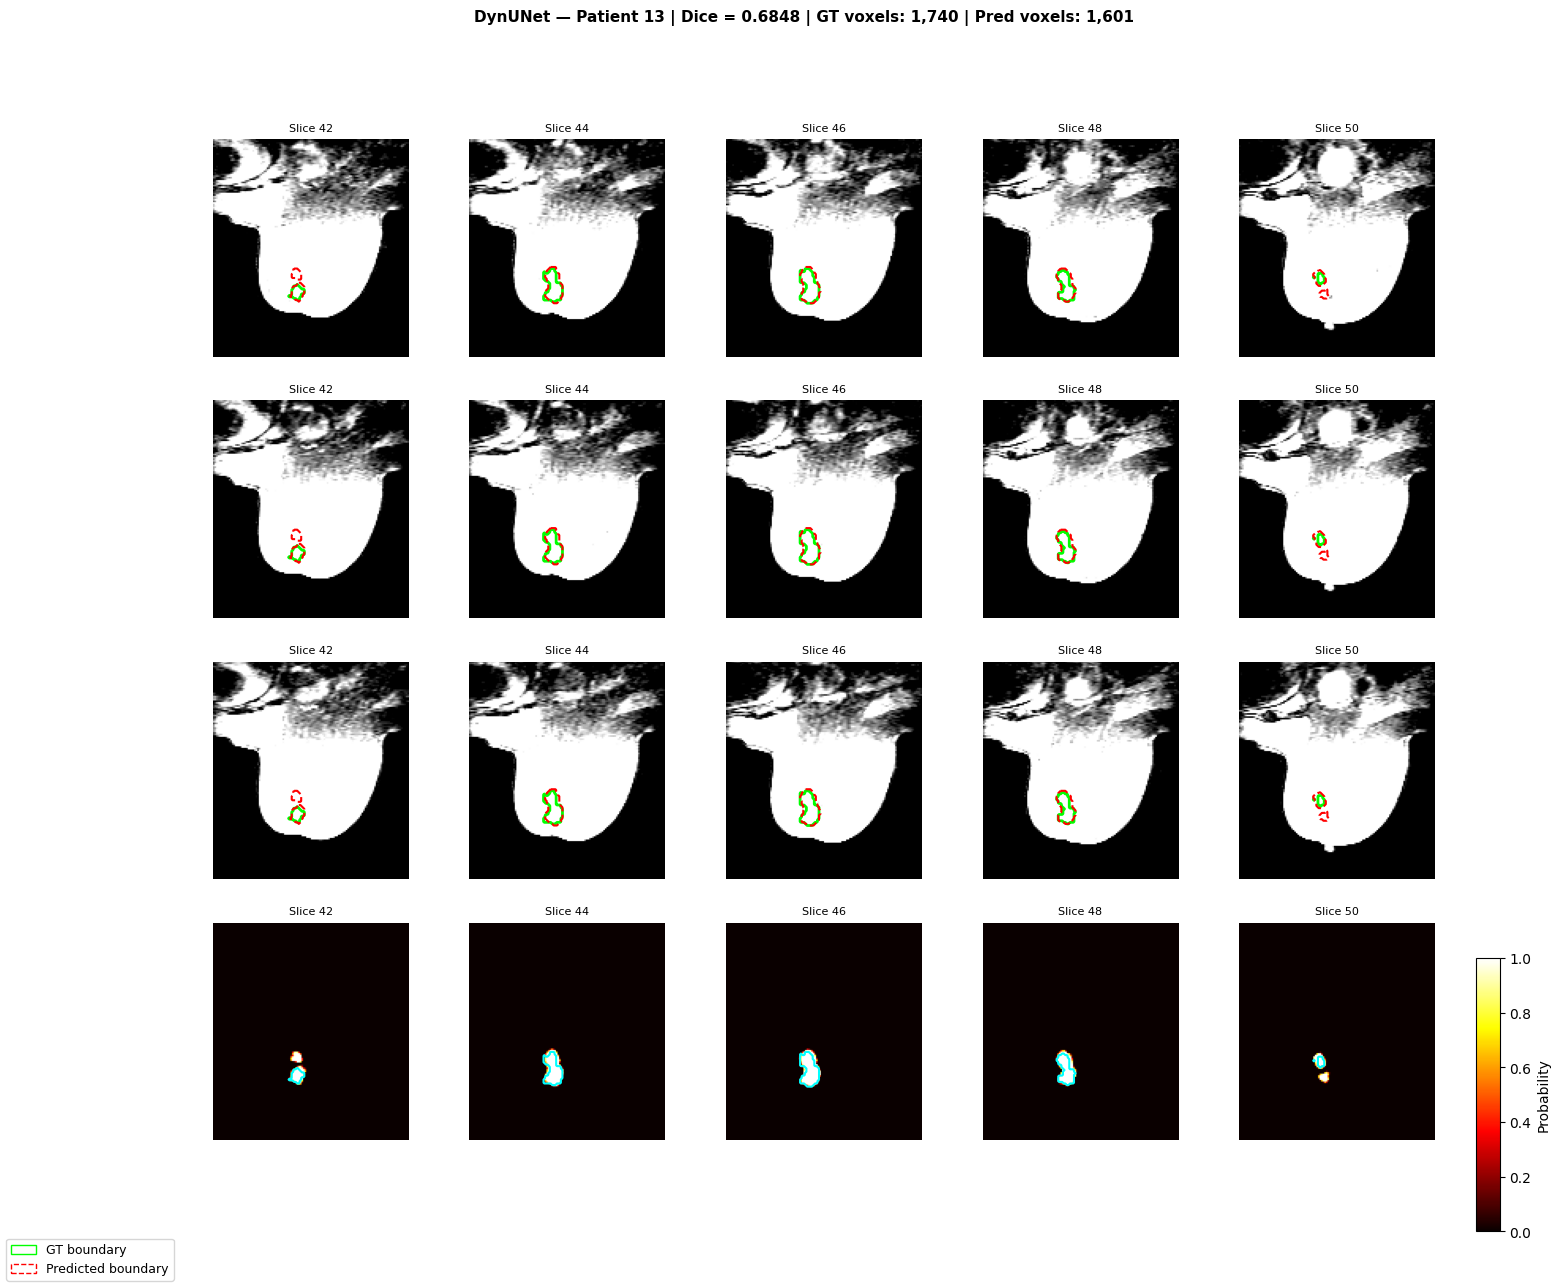

Saved: outputs/dynunet_patient13_overlay.png


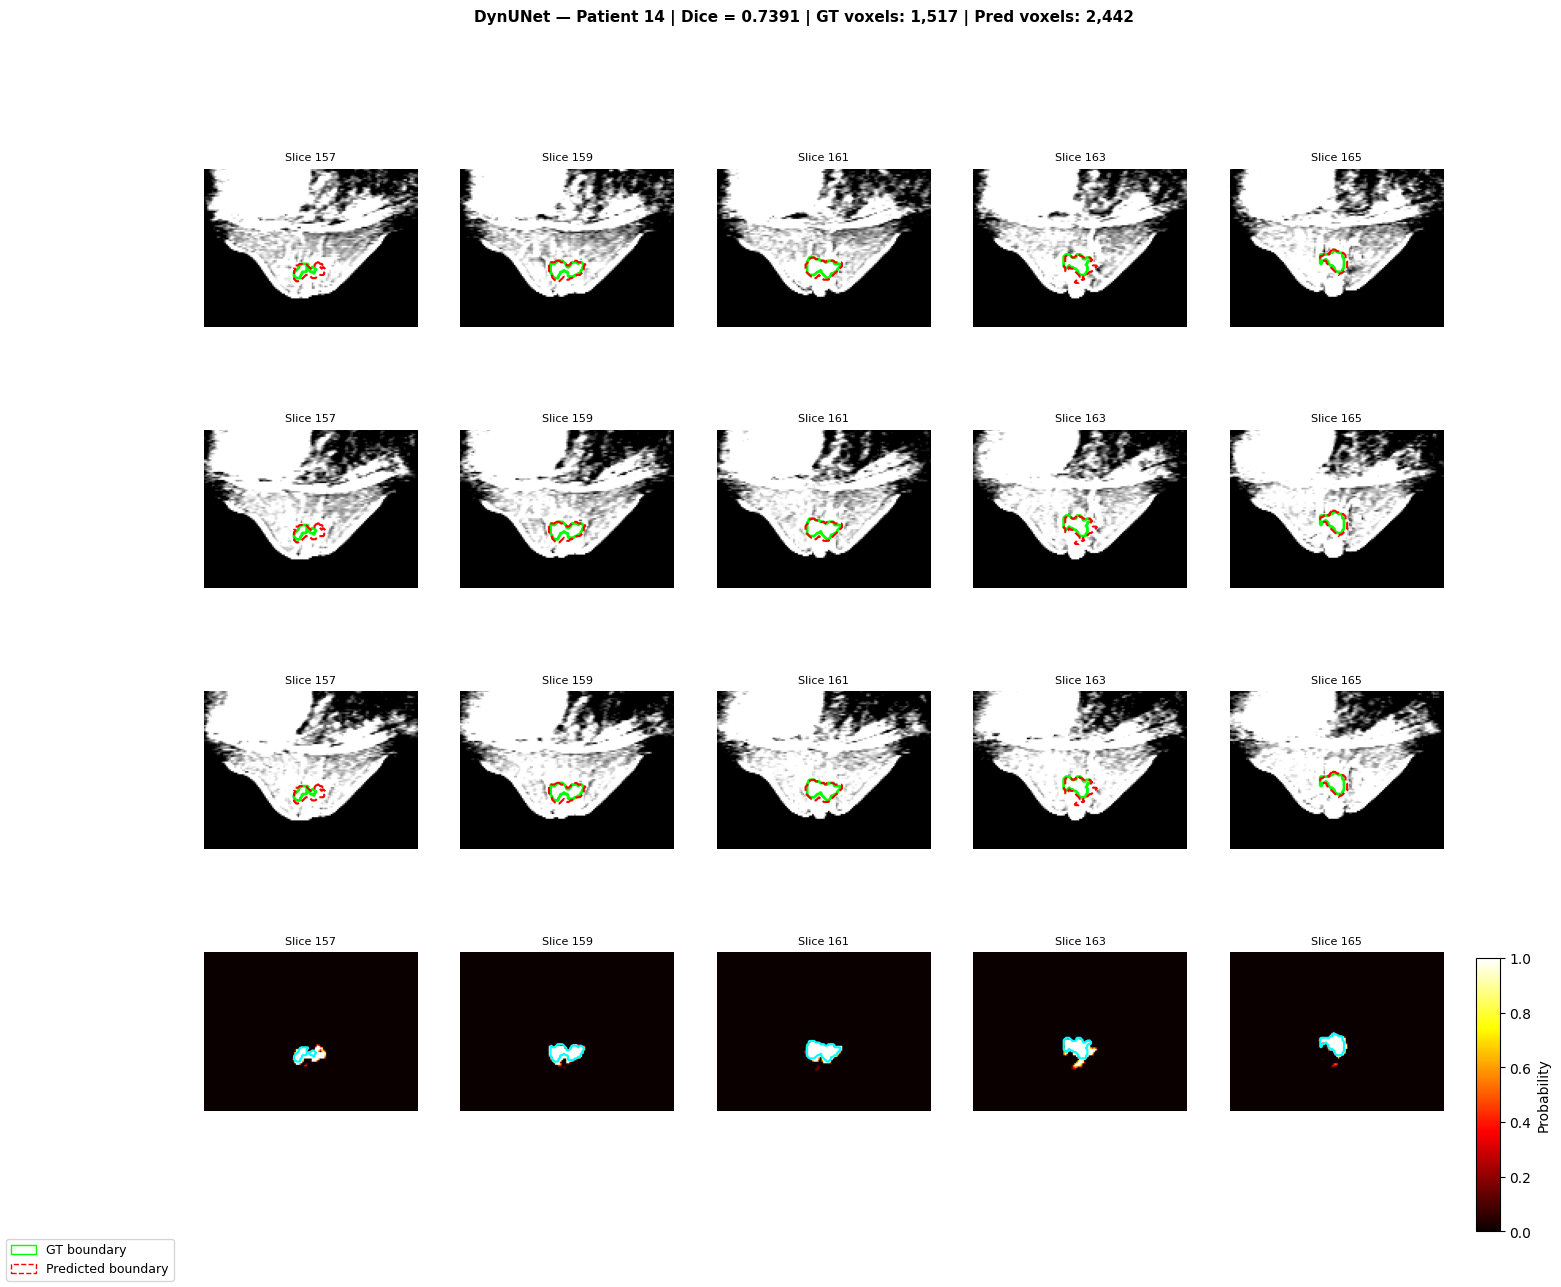

Saved: outputs/dynunet_patient14_overlay.png


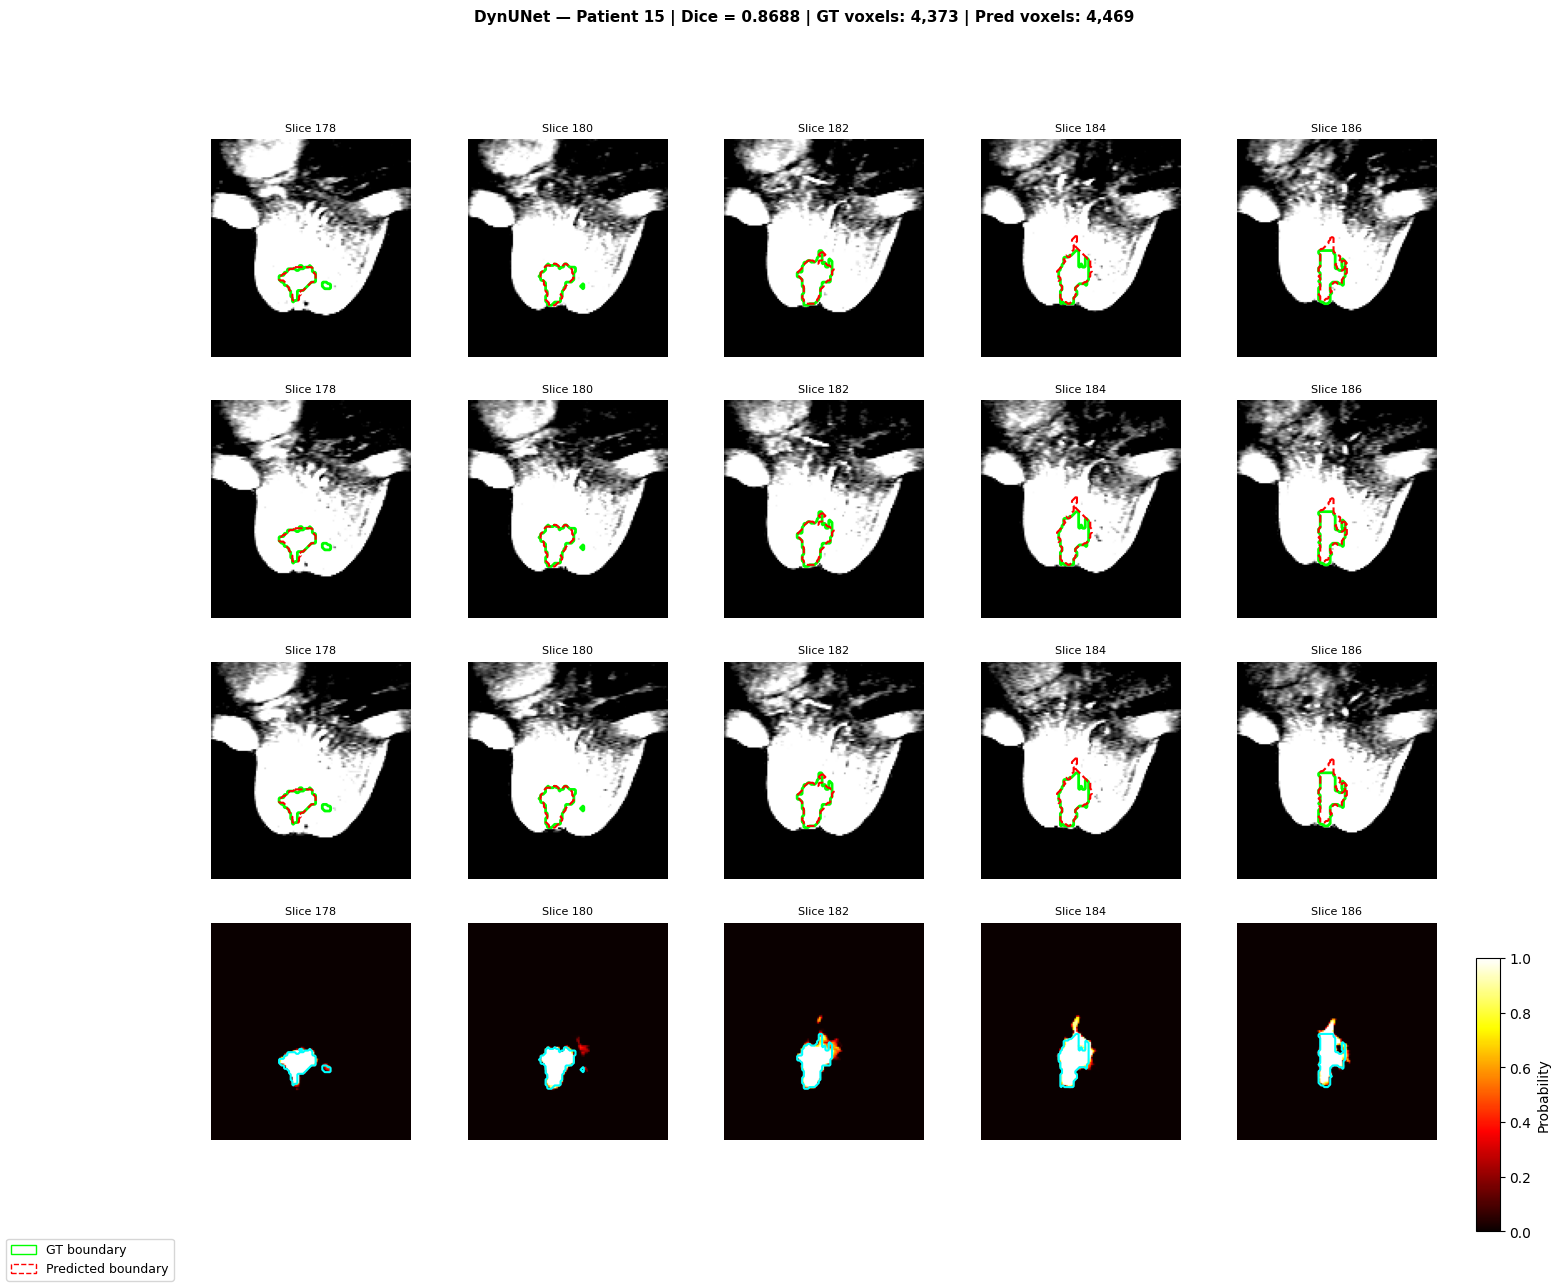

Saved: outputs/dynunet_patient15_overlay.png


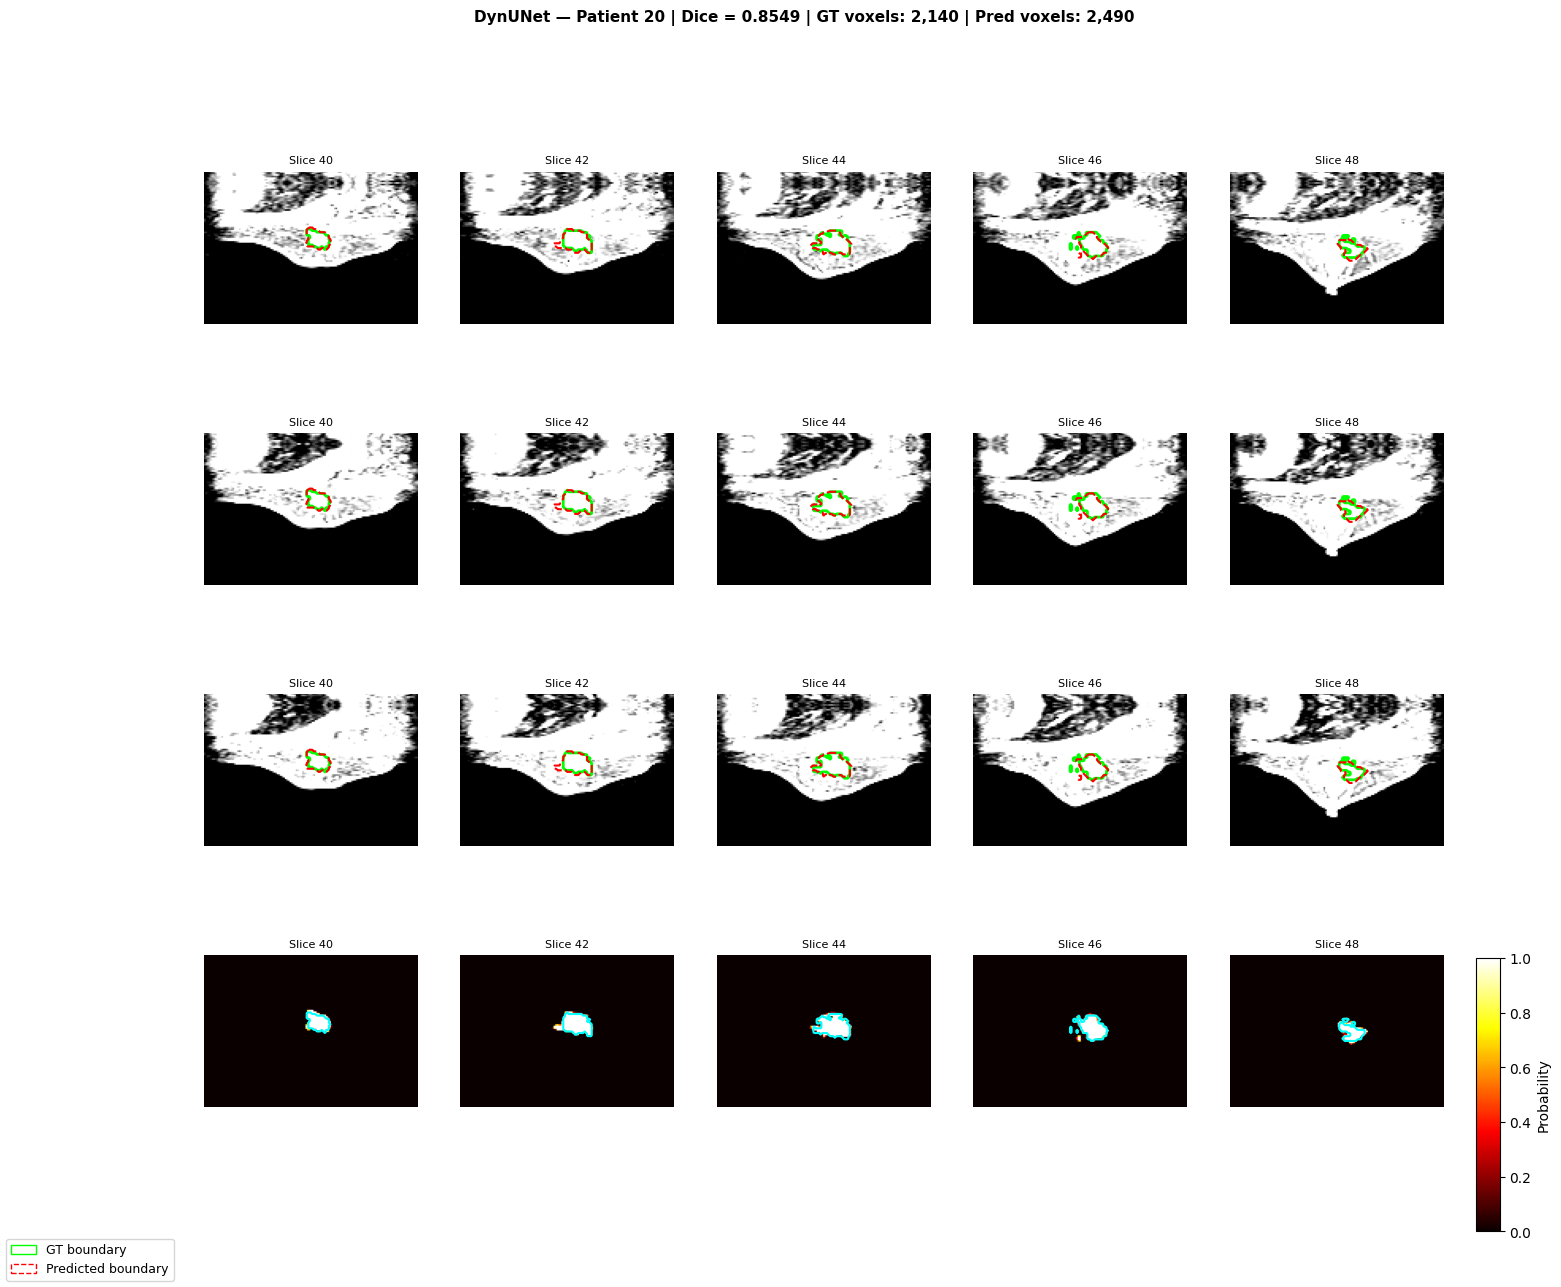

Saved: outputs/dynunet_patient20_overlay.png


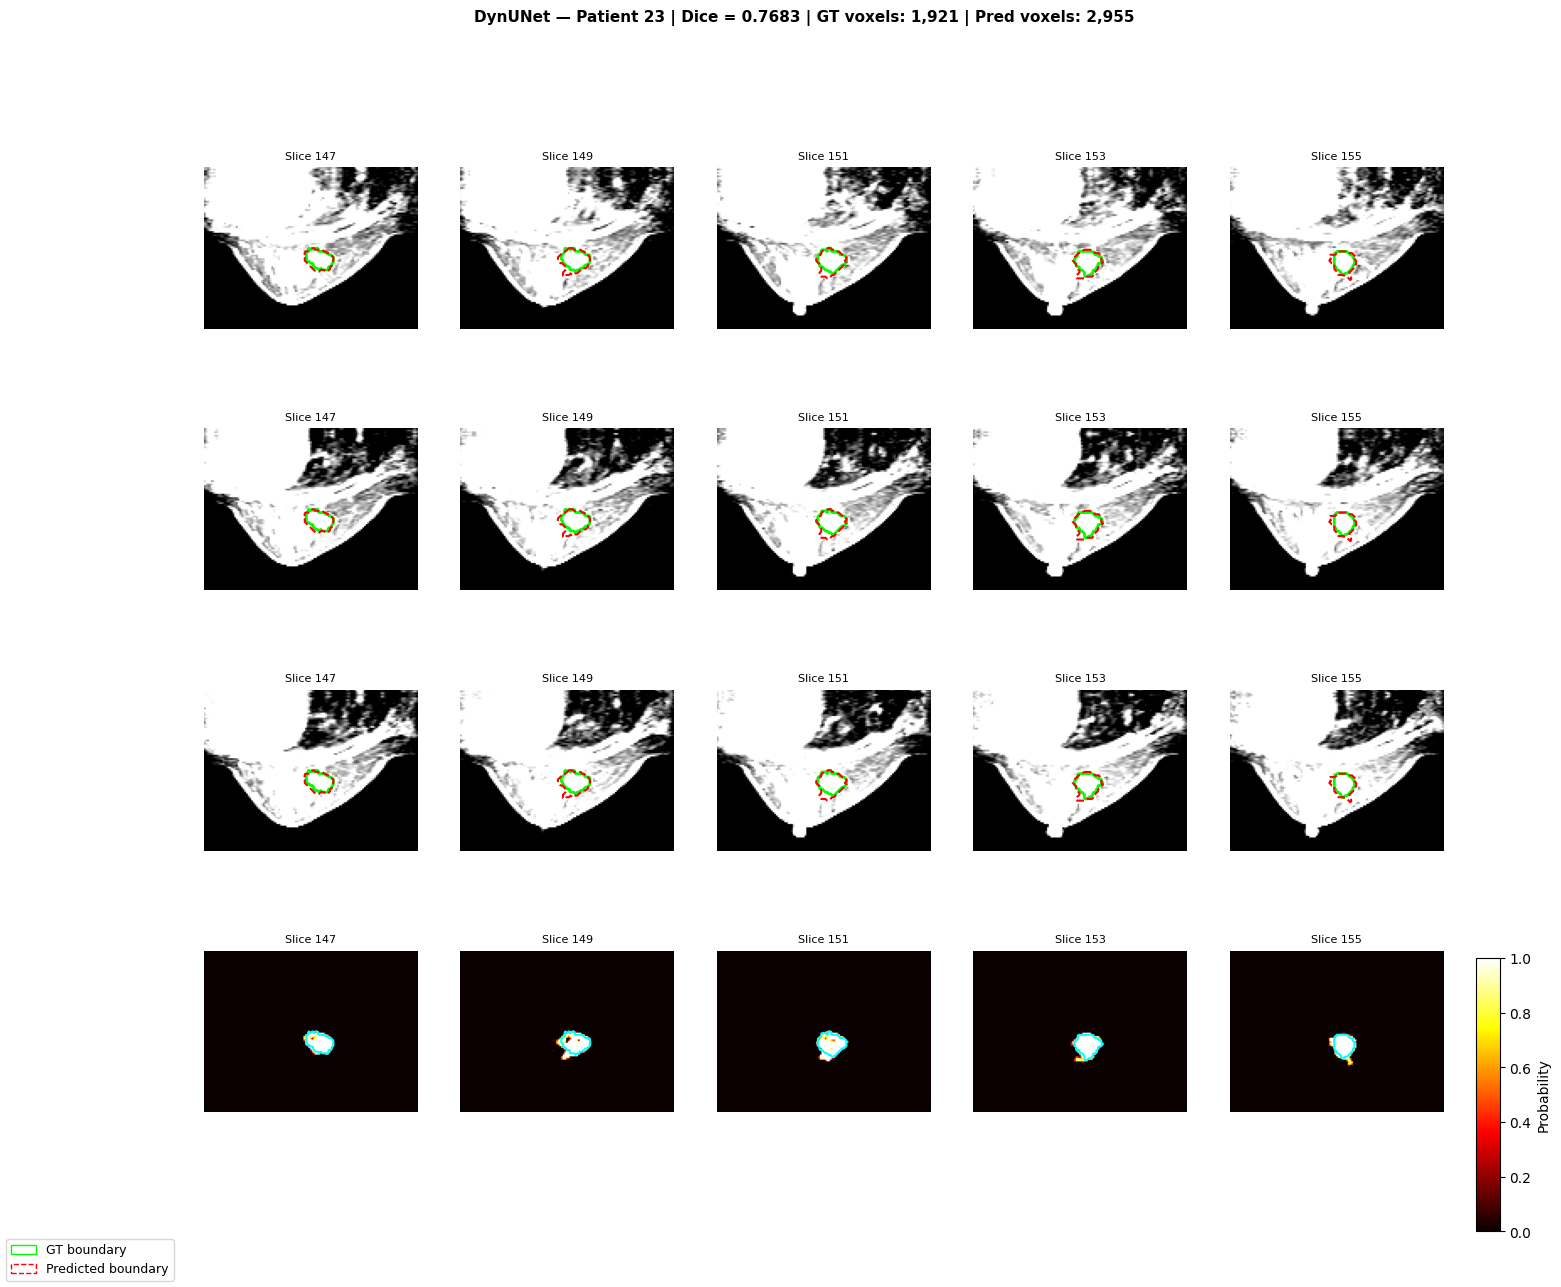

Saved: outputs/dynunet_patient23_overlay.png


In [11]:
# ============================================================
# CELL 8 — GT mask vs Predicted mask overlay
# 4 rows per patient: P1 / P2 / P3 / Probability map
# Green = GT boundary, Red = Predicted boundary
# ============================================================

def visualise_prediction(cache_entry, save_path=None):
    pid   = cache_entry['patient_id']
    image = cache_entry['image']   # (3, D, H, W)
    gt    = cache_entry['gt']      # (D, H, W) bool
    pred  = cache_entry['pred']    # (D, H, W) bool
    prob  = cache_entry['prob']    # (D, H, W) float
    dice  = cache_entry['dice']

    gt_per_slice = gt.sum(axis=(1, 2))
    best_sl      = int(np.argmax(gt_per_slice)) if gt_per_slice.max() > 0 \
                   else image.shape[1] // 2

    D      = image.shape[1]
    slices = [max(0, best_sl - 4), max(0, best_sl - 2), best_sl,
              min(D - 1, best_sl + 2), min(D - 1, best_sl + 4)]
    slices = list(dict.fromkeys(slices))
    n_sl   = len(slices)

    fig, axes = plt.subplots(4, n_sl, figsize=(n_sl * 3.2, 13))
    fig.suptitle(
        f'DynUNet — Patient {pid} | Dice = {dice:.4f} | '
        f'GT voxels: {int(gt.sum()):,} | Pred voxels: {int(pred.sum()):,}',
        fontsize=11, fontweight='bold'
    )

    row_titles = ['P1 (early phase)', 'P2 (mid phase)', 'P3 (late phase)', 'Probability map']

    for col, sl in enumerate(slices):
        for row in range(4):
            ax = axes[row, col]
            if row < 3:
                ax.imshow(image[row, sl], cmap='gray', vmin=0, vmax=1)
                if gt[sl].sum() > 0:
                    ax.contour(gt[sl].astype(float), levels=[0.5],
                               colors='lime', linewidths=2, linestyles='-')
                if pred[sl].sum() > 0:
                    ax.contour(pred[sl].astype(float), levels=[0.5],
                               colors='red', linewidths=1.5, linestyles='--')
            else:
                im = ax.imshow(prob[sl], cmap='hot', vmin=0, vmax=1)
                if gt[sl].sum() > 0:
                    ax.contour(gt[sl].astype(float), levels=[0.5],
                               colors='cyan', linewidths=1.5)

            if col == 0:
                ax.set_ylabel(row_titles[row], fontsize=8)
            ax.set_title(f'Slice {sl}', fontsize=8)
            ax.axis('off')

    cbar_ax = fig.add_axes([0.92, 0.04, 0.015, 0.21])
    sm = plt.cm.ScalarMappable(cmap='hot', norm=plt.Normalize(0, 1))
    fig.colorbar(sm, cax=cbar_ax, label='Probability')

    patches = [
        mpatches.Patch(edgecolor='lime', facecolor='none', label='GT boundary'),
        mpatches.Patch(edgecolor='red',  facecolor='none', label='Predicted boundary', linestyle='--'),
    ]
    fig.legend(handles=patches, loc='lower left', fontsize=9)

    sp = save_path or f'outputs/dynunet_patient{pid}_overlay.png'
    plt.savefig(sp, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {sp}')

# Show all cached patients (up to 6)
if not prob_maps_cache:
    print('No cached predictions — run Cell 7 first.')
else:
    for entry in prob_maps_cache:
        visualise_prediction(entry)


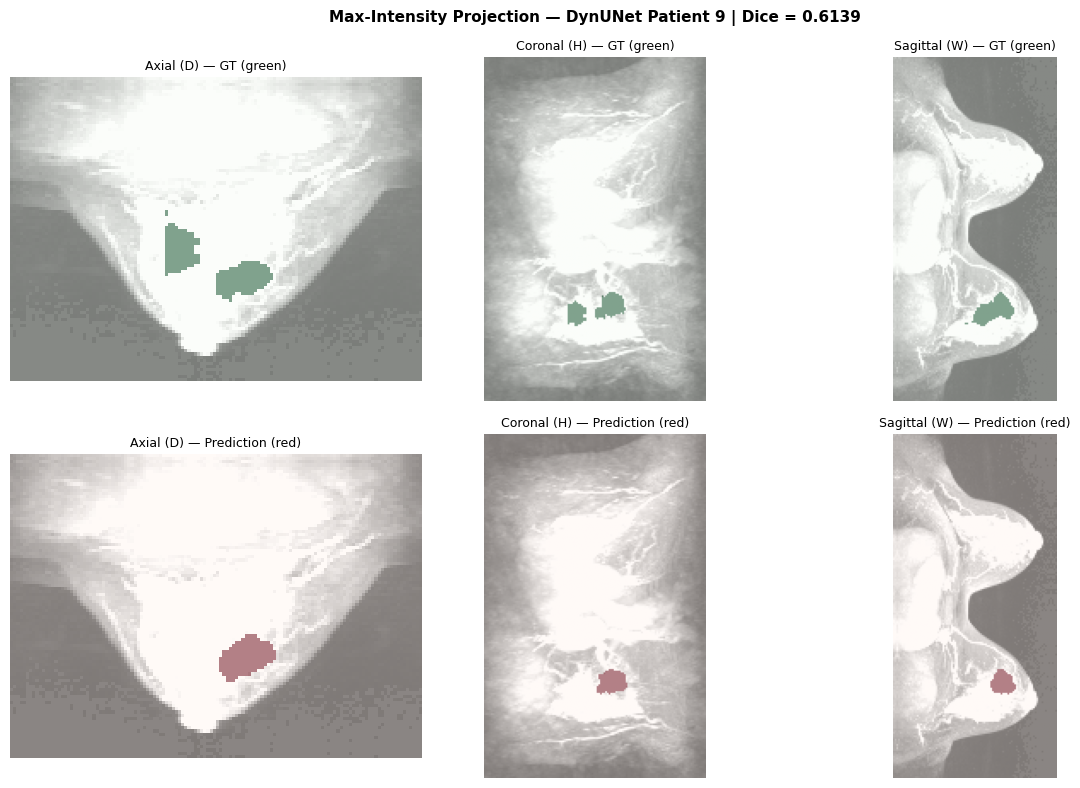

Saved: outputs/dynunet_patient9_mip.png


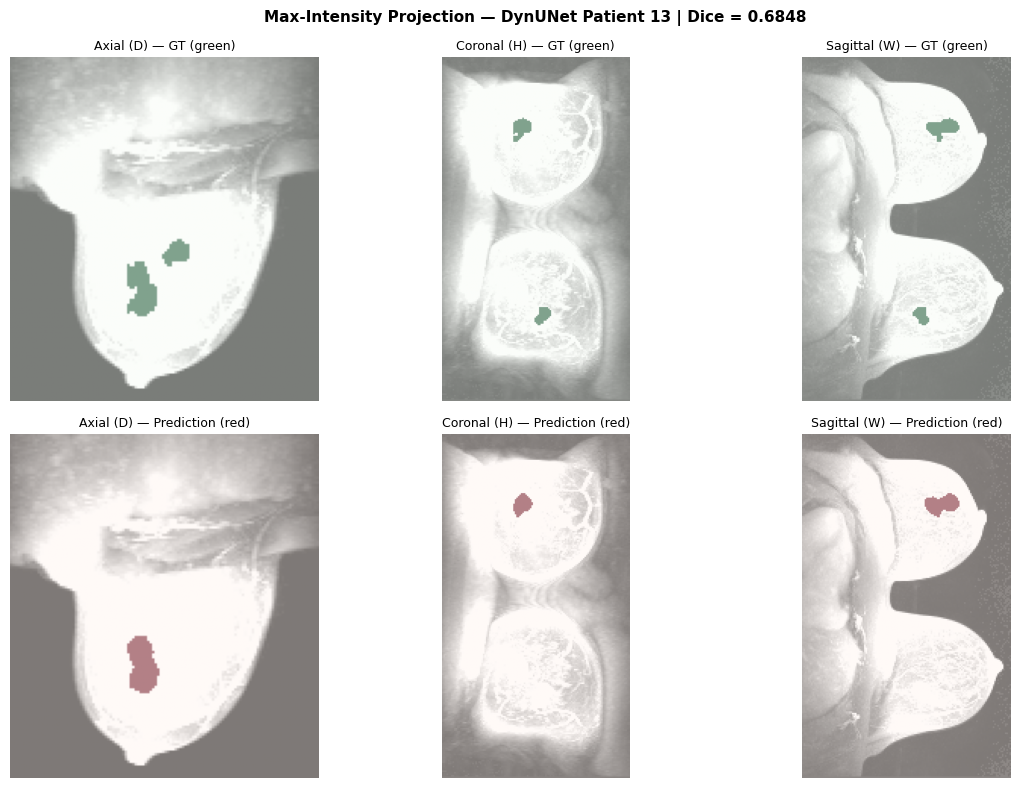

Saved: outputs/dynunet_patient13_mip.png


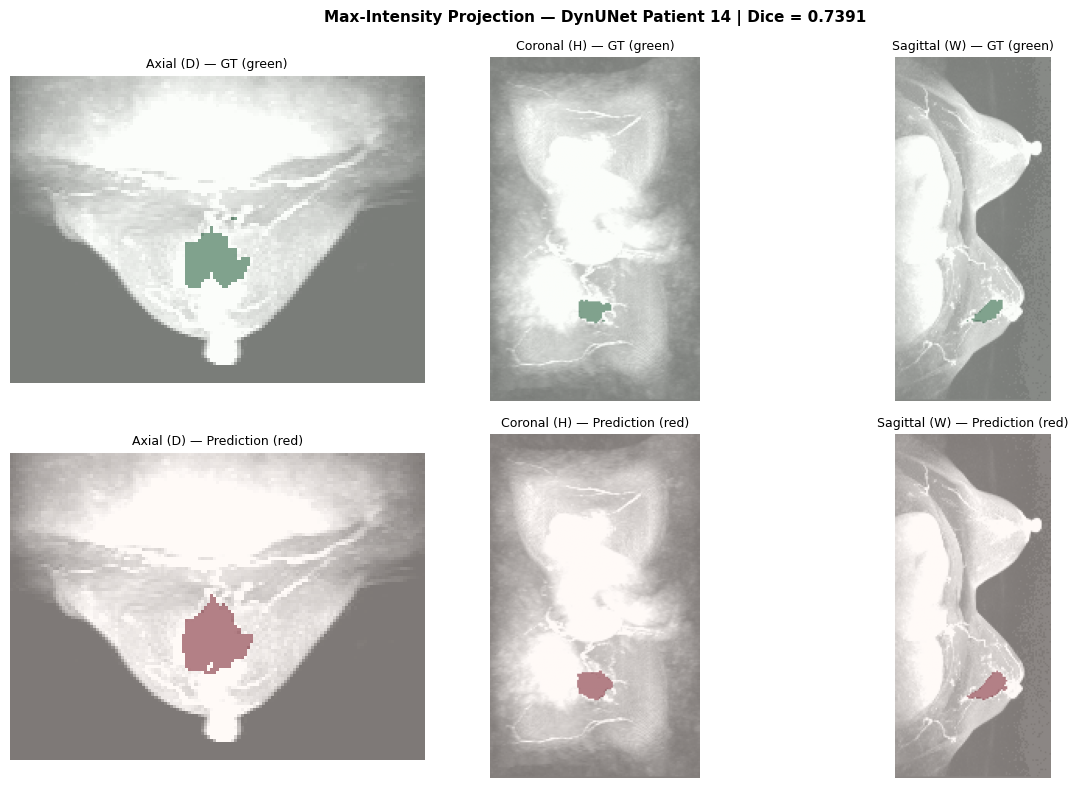

Saved: outputs/dynunet_patient14_mip.png


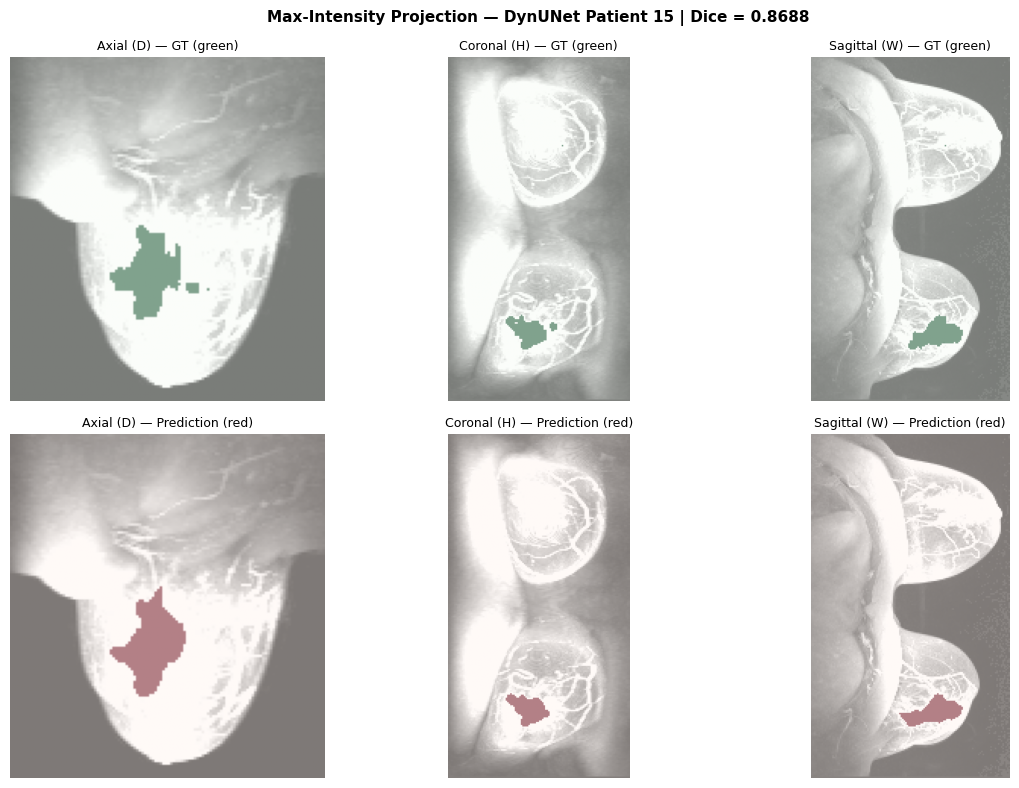

Saved: outputs/dynunet_patient15_mip.png


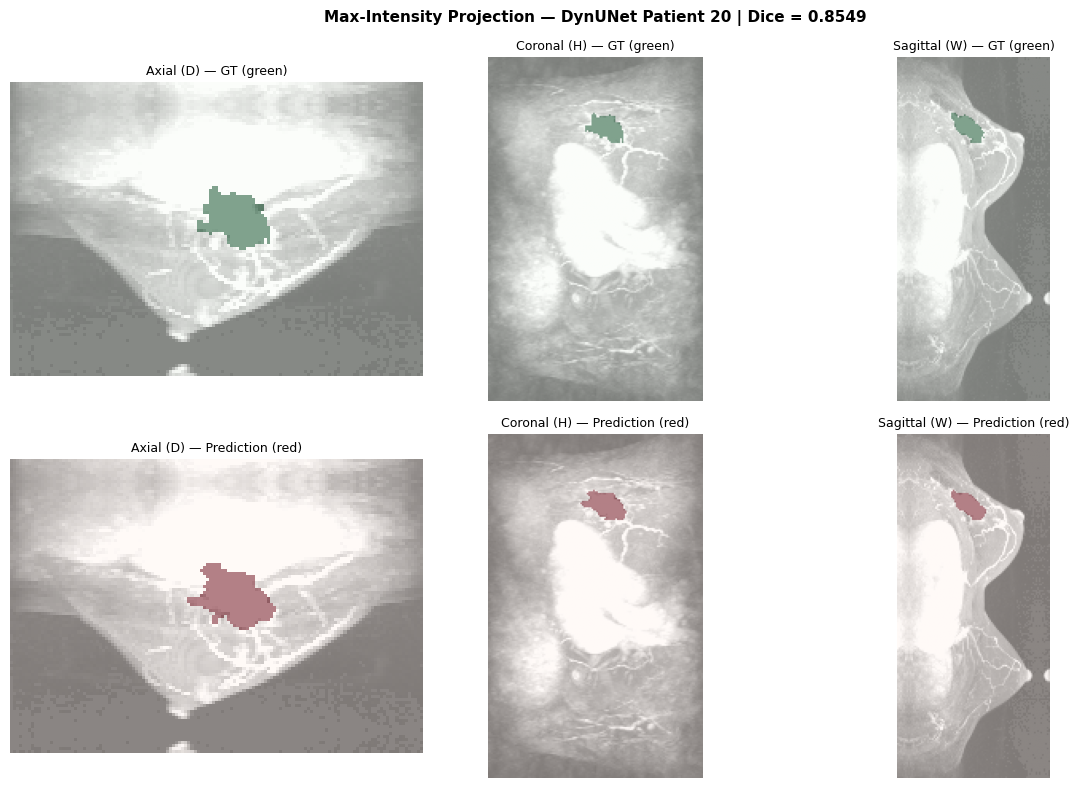

Saved: outputs/dynunet_patient20_mip.png


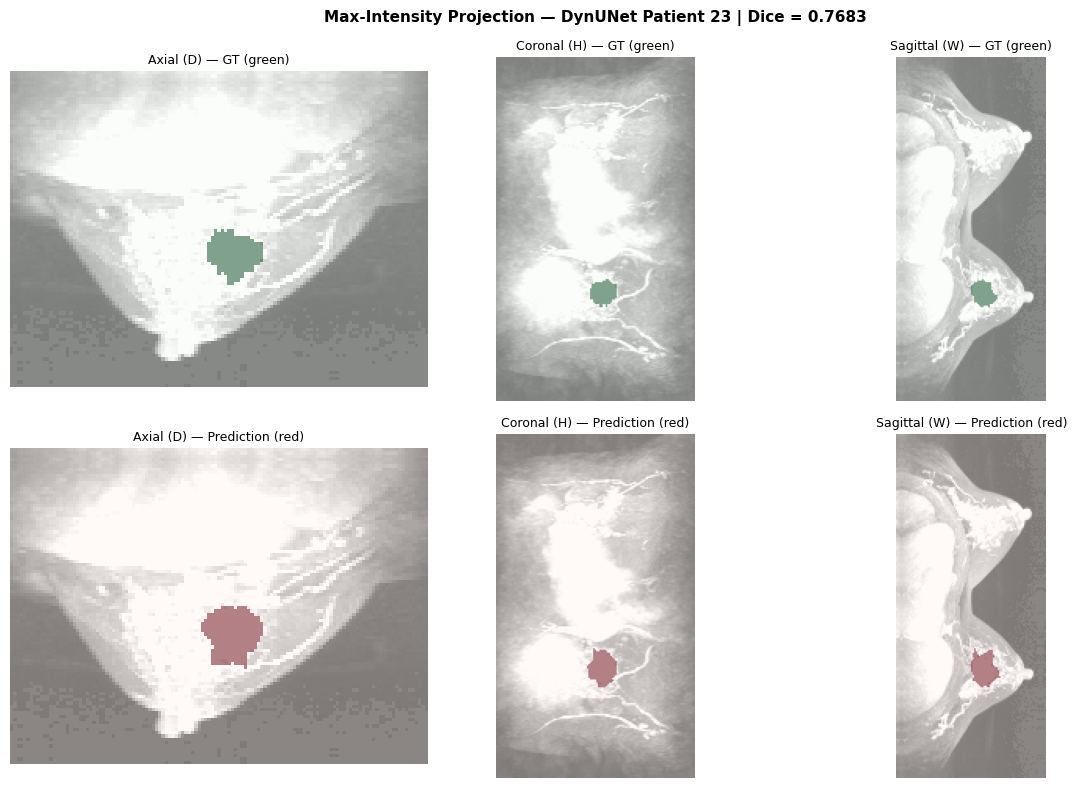

Saved: outputs/dynunet_patient23_mip.png

3D surface render for best patient (Dice = 0.8688)...


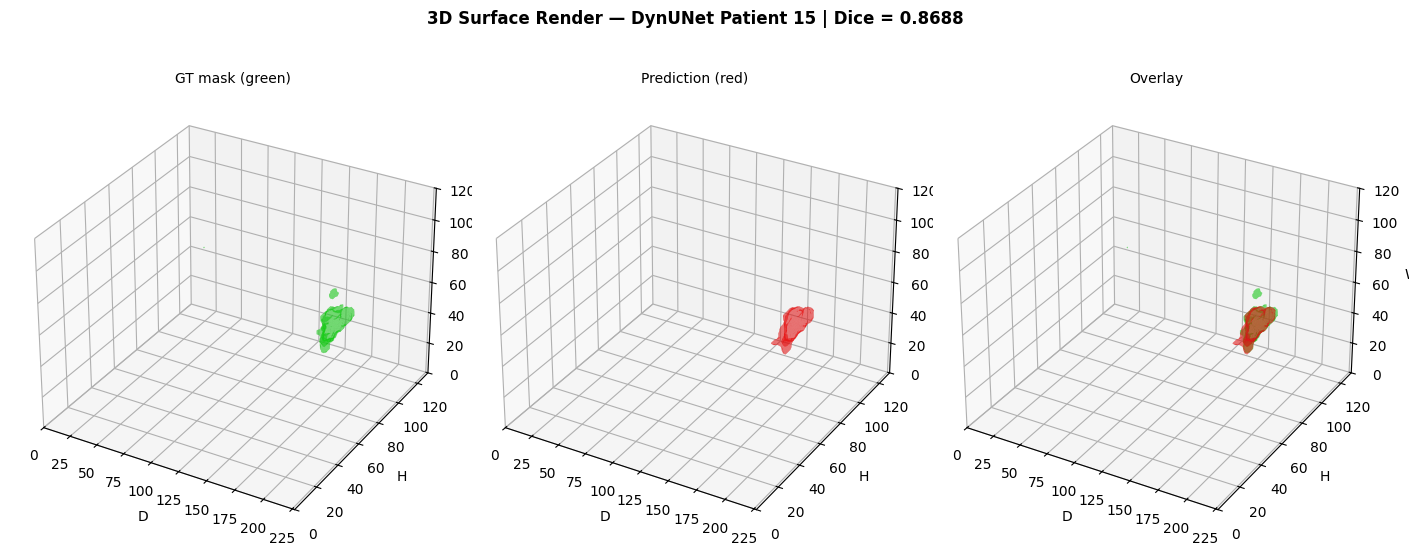

Saved: outputs/dynunet_patient15_3d_render.png


In [12]:
# ============================================================
# CELL 9 — 3D volume rendering: GT vs prediction
# MIP (always works) + marching cubes surface (needs skimage)
# ============================================================

def plot_mip(cache_entry):
    """Max-intensity projection of GT and pred across all 3 axes."""
    gt   = cache_entry['gt'].astype(float)
    pred = cache_entry['pred'].astype(float)
    img  = cache_entry['image'][1]   # P2 channel
    pid  = cache_entry['patient_id']
    dice = cache_entry['dice']

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f'Max-Intensity Projection — DynUNet Patient {pid} | Dice = {dice:.4f}',
                 fontsize=11, fontweight='bold')

    axis_names = ['Axial (D)', 'Coronal (H)', 'Sagittal (W)']
    for col, axis in enumerate([0, 1, 2]):
        mip_img  = img.max(axis=axis)
        mip_gt   = gt.max(axis=axis)
        mip_pred = pred.max(axis=axis)

        ax = axes[0, col]
        ax.imshow(mip_img, cmap='gray')
        ax.imshow(mip_gt,   cmap='Greens', alpha=0.5, vmin=0, vmax=1)
        ax.set_title(f'{axis_names[col]} — GT (green)', fontsize=9)
        ax.axis('off')

        ax = axes[1, col]
        ax.imshow(mip_img, cmap='gray')
        ax.imshow(mip_pred, cmap='Reds',   alpha=0.5, vmin=0, vmax=1)
        ax.set_title(f'{axis_names[col]} — Prediction (red)', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    sp = f'outputs/dynunet_patient{pid}_mip.png'
    plt.savefig(sp, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {sp}')


def plot_3d_surface(cache_entry):
    """3D surface rendering via marching cubes — requires scikit-image."""
    try:
        from mpl_toolkits.mplot3d.art3d import Poly3DCollection
        from skimage import measure
    except ImportError:
        print('scikit-image not installed — skipping 3D surface render.')
        print('Install with: pip install scikit-image')
        return

    gt   = cache_entry['gt']
    pred = cache_entry['pred']
    pid  = cache_entry['patient_id']
    dice = cache_entry['dice']

    fig = plt.figure(figsize=(14, 6))
    fig.suptitle(
        f'3D Surface Render — DynUNet Patient {pid} | Dice = {dice:.4f}',
        fontsize=12, fontweight='bold'
    )

    def add_surface(ax, mask, color, title):
        if mask.sum() < 10:
            ax.text(0.5, 0.5, 0.5, 'No voxels', ha='center', va='center')
            ax.set_title(title); return
        try:
            verts, faces, _, _ = measure.marching_cubes(mask.astype(float), level=0.5)
            mesh = Poly3DCollection(verts[faces], alpha=0.4)
            mesh.set_facecolor(color)
            mesh.set_edgecolor('none')
            ax.add_collection3d(mesh)
            ax.set_xlim(0, mask.shape[0])
            ax.set_ylim(0, mask.shape[1])
            ax.set_zlim(0, mask.shape[2])
        except Exception as err:
            ax.text(0.5, 0.5, 0.5, f'Render error:\n{err}', ha='center', va='center', fontsize=7)
        ax.set_xlabel('D'); ax.set_ylabel('H'); ax.set_zlabel('W')
        ax.set_title(title, fontsize=10)

    ax1 = fig.add_subplot(131, projection='3d')
    add_surface(ax1, gt,   color=[0.1, 0.8, 0.1], title='GT mask (green)')

    ax2 = fig.add_subplot(132, projection='3d')
    add_surface(ax2, pred, color=[0.9, 0.1, 0.1], title='Prediction (red)')

    ax3 = fig.add_subplot(133, projection='3d')
    add_surface(ax3, gt,   color=[0.1, 0.8, 0.1], title='Overlay (GT=green, Pred=red)')
    add_surface(ax3, pred, color=[0.9, 0.1, 0.1], title='Overlay')

    plt.tight_layout()
    sp = f'outputs/dynunet_patient{pid}_3d_render.png'
    plt.savefig(sp, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {sp}')


# Show MIP for all cached patients, then 3D surface for the best one
if not prob_maps_cache:
    print('No cached predictions — run Cell 7 first.')
else:
    for entry in prob_maps_cache:
        plot_mip(entry)

    # 3D surface for best-Dice patient only
    best_entry = max(prob_maps_cache, key=lambda x: x['dice'])
    print(f'\n3D surface render for best patient (Dice = {best_entry["dice"]:.4f})...')
    plot_3d_surface(best_entry)


In [13]:
# ============================================================
# CELL 10 — Per-patient evaluation table
# ============================================================
if not results:
    print('No results — run Cell 7 first.')
else:
    df = pd.DataFrame(results)
    df['dice']      = df['dice'].round(4)
    df['iou']       = df['iou'].round(4)
    df['detected']  = df['detected'].map({True: 'Yes', False: 'No'})
    df['has_tumor'] = df['has_tumor'].map({True: 'Yes', False: 'No'})

    df_display = df[['patient_id', 'dice', 'iou', 'gt_voxels', 'pred_voxels',
                     'has_tumor', 'detected']]
    df_display = df_display.sort_values('dice', ascending=False).reset_index(drop=True)

    print('Per-patient test results — DynUNet (sorted by Dice):')
    print('=' * 65)

    def color_dice(val):
        if val >= 0.7:   return 'background-color: #c8e6c9'
        elif val >= 0.5: return 'background-color: #fff9c4'
        elif val >= 0.3: return 'background-color: #ffe0b2'
        else:            return 'background-color: #ffcdd2'

    styled = df_display.style.map(color_dice, subset=['dice'])
    display(styled)

    csv_path = os.path.join(PROJECT_ROOT, 'outputs', 'dynunet_test_evaluation.csv')
    df_display.to_csv(csv_path, index=False)
    print(f'\nSaved: {csv_path}')

    tumor_mask = df['has_tumor'] == 'Yes'
    print(f'\n  Summary (tumor patients):')
    print(f'  Mean Dice   : {df.loc[tumor_mask, "dice"].mean():.4f}')
    print(f'  Std Dice    : {df.loc[tumor_mask, "dice"].std():.4f}')
    print(f'  Median Dice : {df.loc[tumor_mask, "dice"].median():.4f}')
    print(f'  Best Dice   : {df.loc[tumor_mask, "dice"].max():.4f}')
    print(f'  Worst Dice  : {df.loc[tumor_mask, "dice"].min():.4f}')
    print(f'  vs 2D base  : {df.loc[tumor_mask, "dice"].mean() - BASELINE_2D_DICE:+.4f}')
    print(f'  vs MONAI    : {df.loc[tumor_mask, "dice"].mean() - MONAI_VAL_DICE:+.4f}')


Per-patient test results — DynUNet (sorted by Dice):


,patient_id,dice,iou,gt_voxels,pred_voxels,has_tumor,detected
0,67,0.958200,0.919700,4364,4386,Yes,Yes
1,66,0.918000,0.848300,2496,2818,Yes,Yes
2,78,0.909300,0.833700,1984,2151,Yes,Yes
3,15,0.868800,0.768000,4373,4469,Yes,Yes
4,20,0.854900,0.746500,2140,2490,Yes,Yes
5,54,0.831800,0.712000,19032,24108,Yes,Yes
6,42,0.816600,0.690000,16349,13661,Yes,Yes
7,106,0.802400,0.670000,1814,1733,Yes,Yes
8,23,0.768300,0.623700,1921,2955,Yes,Yes
9,14,0.739100,0.586100,1517,2442,Yes,Yes



Saved: E:\Breast_Tumor_AI_Project\outputs\dynunet_test_evaluation.csv

  Summary (tumor patients):
  Mean Dice   : 0.5188
  Std Dice    : 0.3076
  Median Dice : 0.5889
  Best Dice   : 0.9582
  Worst Dice  : 0.0000
  vs 2D base  : -0.2313
  vs MONAI    : -0.1464


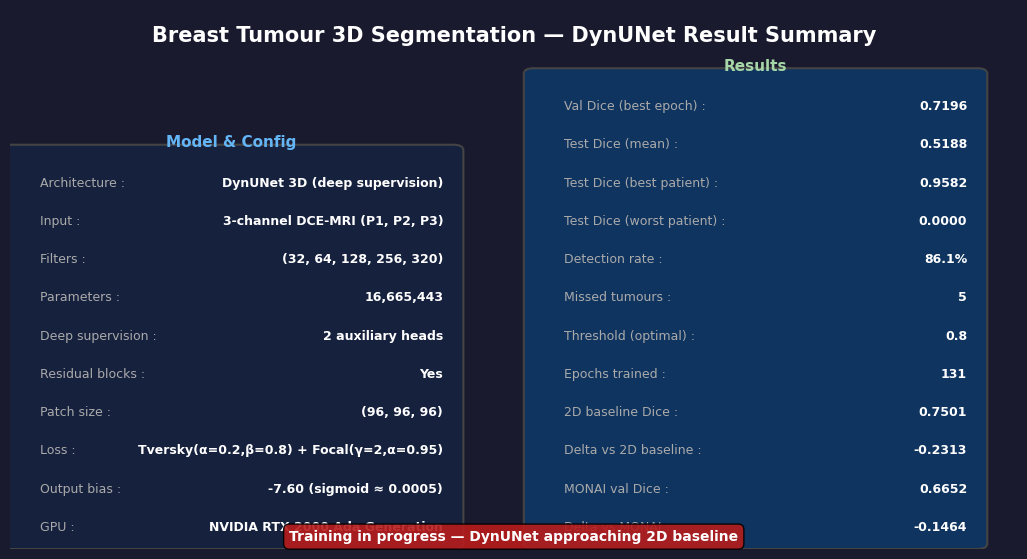

Saved: outputs/summary_card_dynunet.png

  DynUNet Pipeline Complete
  Test Dice     : 0.5188
  2D baseline   : 0.7501
  MONAI val     : 0.6652
  Detection rate: 86.1%
  Next step     : python ensemble_3model.py


In [14]:
# ============================================================
# CELL 11 — Full summary card
# ============================================================
if not results:
    print('No results — run Cell 7 first.')
else:
    tumor_results = [r for r in results if r['has_tumor']]
    mean_dice     = np.mean([r['dice'] for r in tumor_results])
    best_dice     = max([r['dice']  for r in tumor_results])
    worst_dice    = min([r['dice']  for r in tumor_results])
    det_rate      = 100 * sum(r['detected'] for r in tumor_results) / len(tumor_results)
    missed        = sum(1 for r in tumor_results if not r['detected'])
    total_params  = sum(p.numel() for p in model.parameters())

    history_loaded = os.path.exists(HISTORY_FILE)
    if history_loaded:
        h             = np.load(HISTORY_FILE, allow_pickle=True).item()
        best_val_dice = max(h['val_dice'])
        total_epochs  = len(h['val_dice'])
        final_loss    = h['val_loss'][-1]
    else:
        best_val_dice = total_epochs = final_loss = 'N/A'

    fig, ax = plt.subplots(figsize=(13, 7))
    ax.axis('off')
    fig.patch.set_facecolor('#1a1a2e')

    ax.text(0.5, 0.97, 'Breast Tumour 3D Segmentation — DynUNet Result Summary',
            ha='center', va='top', transform=ax.transAxes,
            fontsize=15, fontweight='bold', color='white')

    model_info = [
        ('Architecture',    'DynUNet 3D (deep supervision)'),
        ('Input',           '3-channel DCE-MRI (P1, P2, P3)'),
        ('Filters',         str(DYNUNET_CONFIG['filters'])),
        ('Parameters',      f'{total_params:,}'),
        ('Deep supervision','2 auxiliary heads'),
        ('Residual blocks', 'Yes'),
        ('Patch size',      str(PATCH_SIZE)),
        ('Loss',            'Tversky(\u03b1=0.2,\u03b2=0.8) + Focal(\u03b3=2,\u03b1=0.95)'),
        ('Output bias',     '-7.60 (sigmoid \u2248 0.0005)'),
        ('GPU',             gpu_name),
    ]

    result_info = [
        ('Val Dice (best epoch)',     f'{best_val_dice:.4f}' if isinstance(best_val_dice, float) else best_val_dice),
        ('Test Dice (mean)',          f'{mean_dice:.4f}'),
        ('Test Dice (best patient)',  f'{best_dice:.4f}'),
        ('Test Dice (worst patient)', f'{worst_dice:.4f}'),
        ('Detection rate',            f'{det_rate:.1f}%'),
        ('Missed tumours',            f'{missed}'),
        ('Threshold (optimal)',       f'{INFER_THRESHOLD}'),
        ('Epochs trained',            str(total_epochs)),
        ('2D baseline Dice',          f'{BASELINE_2D_DICE}'),
        ('Delta vs 2D baseline',      f'{mean_dice - BASELINE_2D_DICE:+.4f}'),
        ('MONAI val Dice',            f'{MONAI_VAL_DICE:.4f}'),
        ('Delta vs MONAI',            f'{mean_dice - MONAI_VAL_DICE:+.4f}'),
    ]

    def draw_info_box(ax, title, items, x_start, y_start, box_color, title_color):
        rect = mpatches.FancyBboxPatch(
            (x_start - 0.02, y_start - 0.03),
            0.44, 0.02 + len(items) * 0.071,
            boxstyle='round,pad=0.01',
            facecolor=box_color, edgecolor='#444', linewidth=1.5,
            transform=ax.transAxes, zorder=0
        )
        ax.add_patch(rect)
        ax.text(x_start + 0.20, y_start + len(items) * 0.071 - 0.01, title,
                ha='center', va='bottom', transform=ax.transAxes,
                fontsize=11, fontweight='bold', color=title_color)
        for i, (label, val) in enumerate(items):
            y = y_start + (len(items) - 1 - i) * 0.071
            ax.text(x_start + 0.01, y, label + ' :',
                    ha='left', va='center', transform=ax.transAxes,
                    fontsize=9, color='#aaa')
            ax.text(x_start + 0.41, y, str(val),
                    ha='right', va='center', transform=ax.transAxes,
                    fontsize=9, color='white', fontweight='bold')

    draw_info_box(ax, 'Model & Config', model_info,
                  0.02, 0.04, '#16213e', '#64b5f6')
    draw_info_box(ax, 'Results', result_info,
                  0.54, 0.04, '#0f3460', '#a5d6a7')

    status_color = '#1b5e20' if mean_dice >= BASELINE_2D_DICE else '#b71c1c'
    status_text  = ('DynUNet surpassed 2D baseline \u2714' if mean_dice >= BASELINE_2D_DICE
                    else 'Training in progress — DynUNet approaching 2D baseline')
    ax.text(0.5, 0.01, status_text,
            ha='center', va='bottom', transform=ax.transAxes,
            fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=status_color, alpha=0.9))

    plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'summary_card_dynunet.png'),
                dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()

    print('Saved: outputs/summary_card_dynunet.png')
    print('\n' + '=' * 55)
    print('  DynUNet Pipeline Complete')
    print('=' * 55)
    print(f'  Test Dice     : {mean_dice:.4f}')
    print(f'  2D baseline   : {BASELINE_2D_DICE}')
    print(f'  MONAI val     : {MONAI_VAL_DICE:.4f}')
    print(f'  Detection rate: {det_rate:.1f}%')
    print(f'  Next step     : python ensemble_3model.py')
